# ВЫПОЛНИЛ РАБОТУ БУГРЕНКОВ ВЛАДИМИР М8О-311Б-23

писят два

![alt text](image.png)

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tabulate import tabulate

from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression
import warnings
from sklearn.preprocessing import PolynomialFeatures
warnings.filterwarnings('ignore')
train = pd.read_csv('train_c.csv')
test = pd.read_csv('test_c.csv')



## задача 1) разведочный анализ данных (EDA): построить графики зависимости некоторых признаков друг от друга, график целевой переменной и матрицу корреляций, сделать выводы.

## Информация о данных

In [38]:
missing_train = train.isnull().sum()
missing_percent = 100 * missing_train / len(train)
missing_df = pd.DataFrame({
    'Признак': missing_train.index,
    'Пропусков': missing_train.values,
    'Процент': missing_percent.values
})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)

if len(missing_df) > 0:
    styled = missing_df.style.format({
        'Пропусков': '{:d}',
        'Процент': '{:.2f}'
    }).set_properties(**{
        'text-align': 'center',
        'color': 'white',
        'background-color': '#333'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
        {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
    ])
    print(f"\n  Пропуски в {len(missing_df)} признаках:")
    display(styled)
else:
    print("Пропущенных значений нет")



  Пропуски в 35 признаках:


,Признак,Пропусков,Процент
21,TotalAssets,1031,9.36
3,CreditScore,1031,9.36
4,LoanAmount,1031,9.36
30,BaseInterestRate,1031,9.36
29,NetWorth,1031,9.36
9,MonthlyDebtPayments,1031,9.36
20,CheckingAccountBalance,1031,9.36
15,LoanPurpose,1031,9.36
14,BankruptcyHistory,1031,9.36
25,JobTenure,530,4.81


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency

##  корреляционный анализ

,Класс,Количество,Процент
0,Rejected (0),5120,46.47%
1,Approved (1),5367,48.72%


Соотношение классов: 1.05:1
Существенного дисбаланса классов не наблюдается.


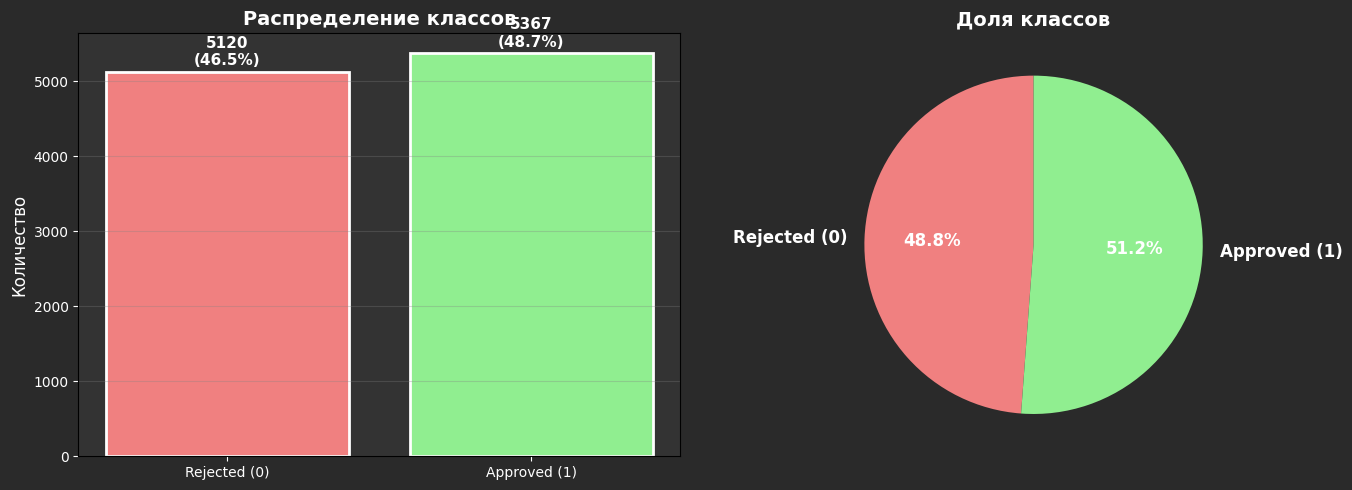

,Признак,Chi2,P-value,Cramers_V,Связь
4,EducationLevel,53.93,5.44e-11,0.0717,Есть
2,LoanPurpose,7.10,1.31e-01,0.0267,Нет
3,EmploymentStatus,5.76,5.62e-02,0.0234,Нет
0,MaritalStatus,5.39,1.45e-01,0.0227,Нет
1,HomeOwnershipStatus,2.89,4.09e-01,0.0166,Нет


Point-Biserial корреляция признаков с LoanApproved:


,Признак,Корреляция,P-value
0,MonthlyIncome,0.7549,0.00e+00
1,AnnualIncome,0.7430,0.00e+00
2,BaseInterestRate,-0.6052,0.00e+00
3,InterestRate,-0.5992,0.00e+00
4,CreditScore,0.5818,0.00e+00
5,TotalDebtToIncomeRatio,-0.4762,0.00e+00
6,MonthlyLoanPayment,-0.2174,2.25e-112
7,LoanAmount,-0.1956,1.07e-86
8,NetWorth,0.1296,1.12e-38
9,TotalAssets,0.1292,1.96e-38


Максимальная положительная корреляция: 0.7549 (MonthlyIncome)
Средняя абсолютная корреляция: 0.1720
Медианная абсолютная корреляция: 0.0376
Распределение силы корреляций:
  Сильная положительная (>0.1):       5 признаков
  Умеренная положительная (0.05-0.1): 0 признаков
  Слабая положительная (0-0.05):      7 признаков
  Слабая отрицательная (-0.05-0):     11 признаков
  Умеренная отрицательная (-0.1--0.05): 0 признаков
  Сильная отрицательная (<-0.1):      5 признаков
Признаки с сильной положительной корреляцией (>0.1):


,Признак,Корреляция,P-value
0,MonthlyIncome,0.7549,0.00e+00
1,AnnualIncome,0.7430,0.00e+00
4,CreditScore,0.5818,0.00e+00
8,NetWorth,0.1296,1.12e-38
9,TotalAssets,0.1292,1.96e-38


Признаки с сильной отрицательной корреляцией (<-0.1):


,Признак,Корреляция,P-value
2,BaseInterestRate,-0.6052,0.00e+00
3,InterestRate,-0.5992,0.00e+00
5,TotalDebtToIncomeRatio,-0.4762,0.00e+00
6,MonthlyLoanPayment,-0.2174,2.25e-112
7,LoanAmount,-0.1956,1.07e-86


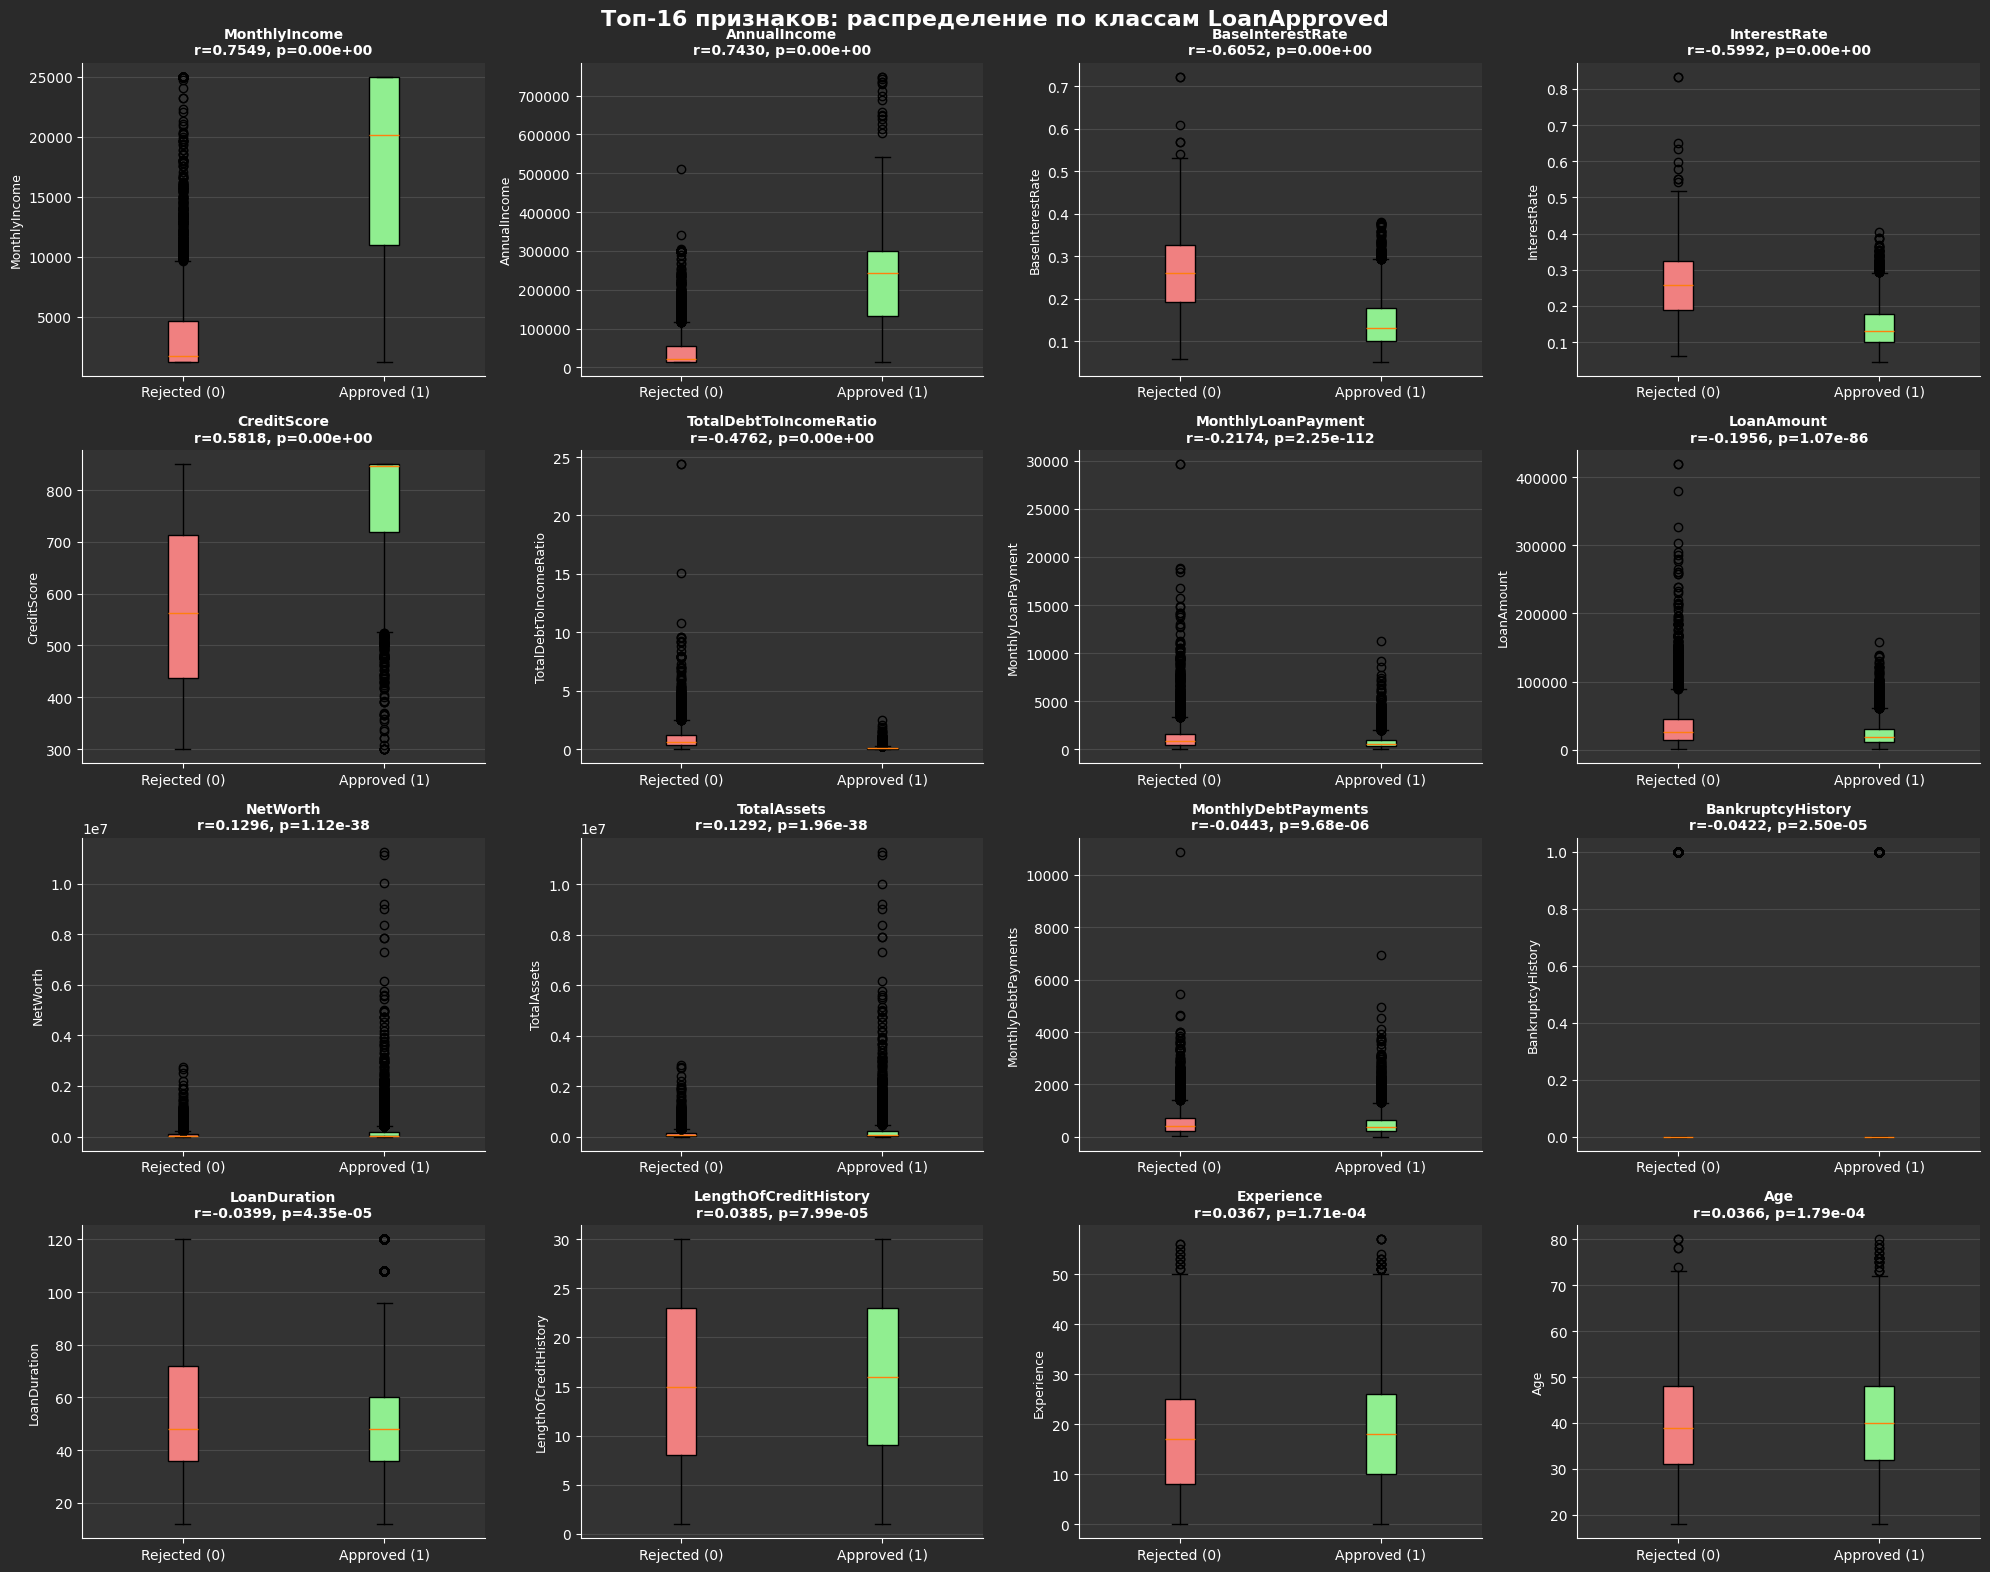

Топ-20 парных корреляций:


,Feature_1,Feature_2,Correlation,Abs_Correlation
328,TotalAssets,NetWorth,0.9940,0.9940
44,AnnualIncome,MonthlyIncome,0.9854,0.9854
21,Age,Experience,0.9830,0.9830
372,BaseInterestRate,InterestRate,0.9754,0.9754
74,CreditScore,BaseInterestRate,-0.9318,0.9318
75,CreditScore,InterestRate,-0.9076,0.9076
100,LoanAmount,MonthlyLoanPayment,0.8725,0.8725
69,CreditScore,MonthlyIncome,0.6277,0.6277
27,AnnualIncome,CreditScore,0.6172,0.6172
374,BaseInterestRate,TotalDebtToIncomeRatio,0.6052,0.6052


Общее количество уникальных пар признаков: 378
Распределение парных корреляций по диапазонам:
  |r| в диапазоне 0.0-0.1:  349 пар (92.33%)
  |r| в диапазоне 0.1-0.2:    2 пар ( 0.53%)
  |r| в диапазоне 0.2-0.3:    5 пар ( 1.32%)
  |r| в диапазоне 0.3-0.4:    2 пар ( 0.53%)
  |r| в диапазоне 0.4-0.5:    3 пар ( 0.79%)
  |r| в диапазоне 0.5-0.6:    6 пар ( 1.59%)
  |r| в диапазоне 0.6-0.7:    4 пар ( 1.06%)
  |r| в диапазоне 0.7-0.8:    0 пар ( 0.00%)
  |r| в диапазоне 0.8-0.9:    1 пар ( 0.26%)
  |r| в диапазоне 0.9-1.0:    6 пар ( 1.59%)
Статистика по абсолютным значениям корреляций:
  Минимальная абсолютная корреляция: 0.000026
  Максимальная абсолютная корреляция: 0.994042
  Средняя абсолютная корреляция:     0.051546
  Медианная абсолютная корреляция:   0.007410
  Стандартное отклонение:            0.163392
Пары с высокой корреляцией:
  |r| > 0.1:   29 пар ( 7.67%)
  |r| > 0.2:   27 пар ( 7.14%)
  |r| > 0.3:   22 пар ( 5.82%)
  |r| > 0.4:   20 пар ( 5.29%)
  |r| > 0.5:   17 пар ( 4.

,Feature,Mean_Abs_Corr,Median_Abs_Corr,Max_Abs_Corr,Min_Abs_Corr,Corr_>0.3,Corr_>0.5,Corr_>0.7,LoanApproved_Corr
23,NetWorth,0.0478,0.0080,0.9940,0.0001,1,1,1,0.1296
17,TotalAssets,0.0463,0.0080,0.9940,0.0006,1,1,1,0.1292
1,AnnualIncome,0.1292,0.0097,0.9854,0.0009,5,4,1,0.7430
19,MonthlyIncome,0.1306,0.0112,0.9854,0.0008,5,4,1,0.7549
0,Age,0.0517,0.0128,0.9830,0.0002,1,1,1,0.0366
22,Experience,0.0521,0.0123,0.9830,0.0000,1,1,1,0.0367
25,InterestRate,0.1727,0.0172,0.9754,0.0001,6,5,2,-0.5992
24,BaseInterestRate,0.1749,0.0156,0.9754,0.0001,6,5,2,-0.6052
2,CreditScore,0.1474,0.0108,0.9318,0.0003,5,5,2,0.5818
3,LoanAmount,0.0772,0.0063,0.8725,0.0005,2,1,1,-0.1956


Топ-10 признаков с наибольшей средней корреляцией с другими:


,Feature,Mean_Abs_Corr,Max_Abs_Corr,LoanApproved_Corr
24,BaseInterestRate,0.1749,0.9754,-0.6052
25,InterestRate,0.1727,0.9754,-0.5992
27,TotalDebtToIncomeRatio,0.1524,0.6052,-0.4762
2,CreditScore,0.1474,0.9318,0.5818
19,MonthlyIncome,0.1306,0.9854,0.7549
1,AnnualIncome,0.1292,0.9854,0.7430
26,MonthlyLoanPayment,0.1002,0.8725,-0.2174
3,LoanAmount,0.0772,0.8725,-0.1956
22,Experience,0.0521,0.9830,0.0367
0,Age,0.0517,0.9830,0.0366


Признаки с наибольшим количеством высоких корреляций:


,Feature,Corr_>0.3,Corr_>0.5,Corr_>0.7,Max_Abs_Corr
25,InterestRate,6,5,2,0.9754
24,BaseInterestRate,6,5,2,0.9754
2,CreditScore,5,5,2,0.9318
1,AnnualIncome,5,4,1,0.9854
19,MonthlyIncome,5,4,1,0.9854
27,TotalDebtToIncomeRatio,7,4,0,0.6052
26,MonthlyLoanPayment,4,2,1,0.8725
23,NetWorth,1,1,1,0.9940
17,TotalAssets,1,1,1,0.9940
0,Age,1,1,1,0.9830


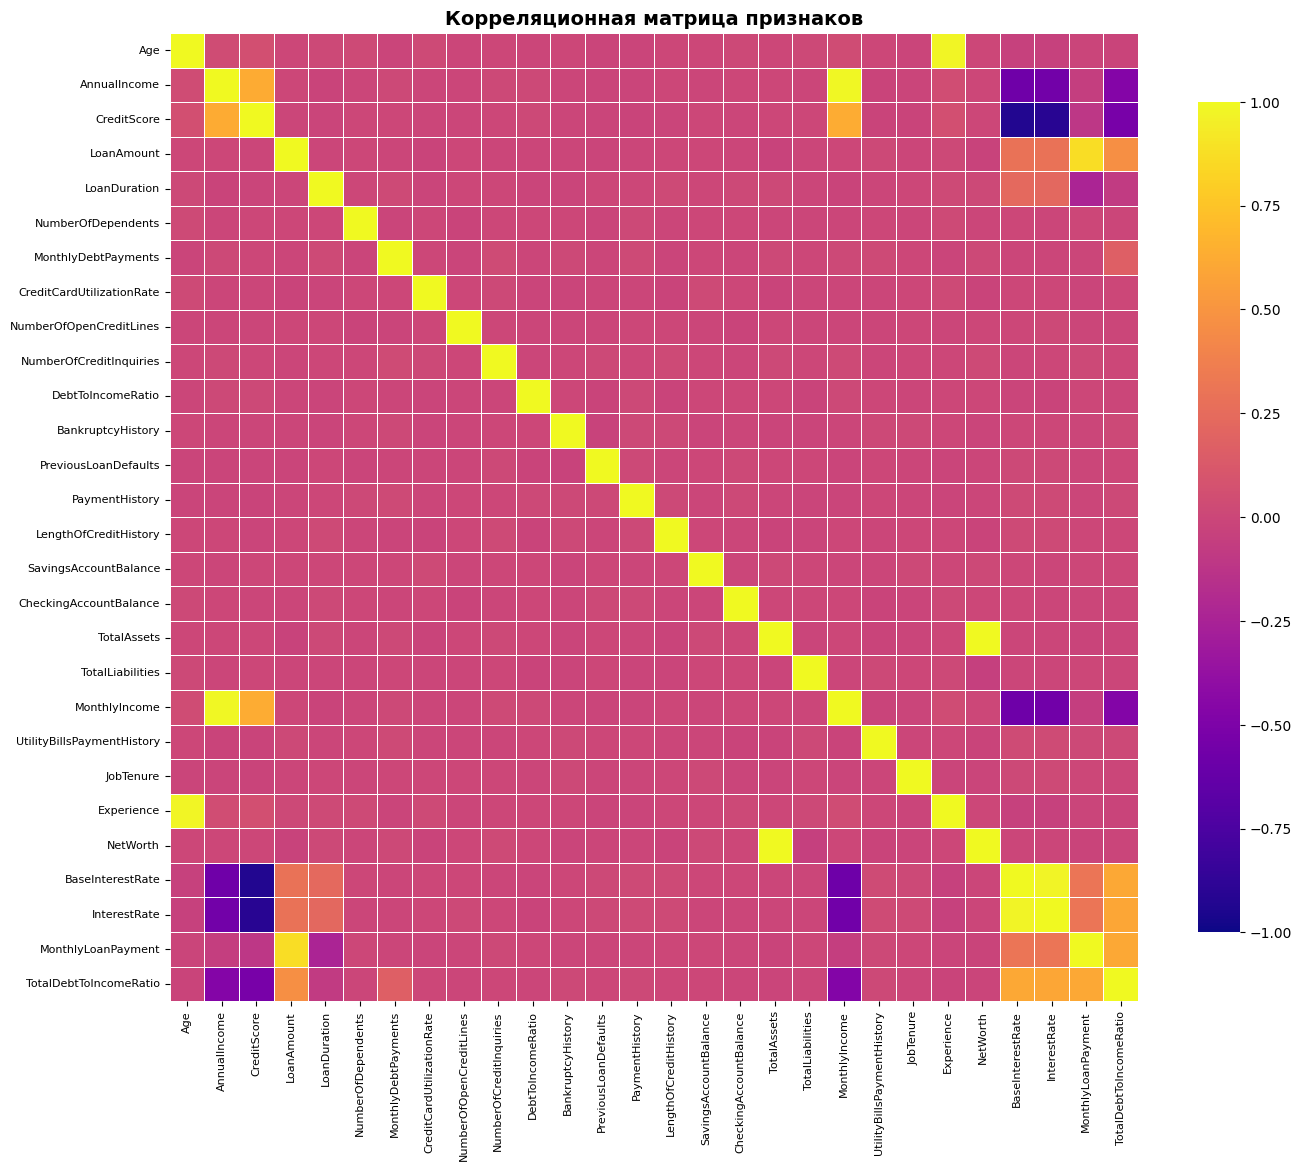

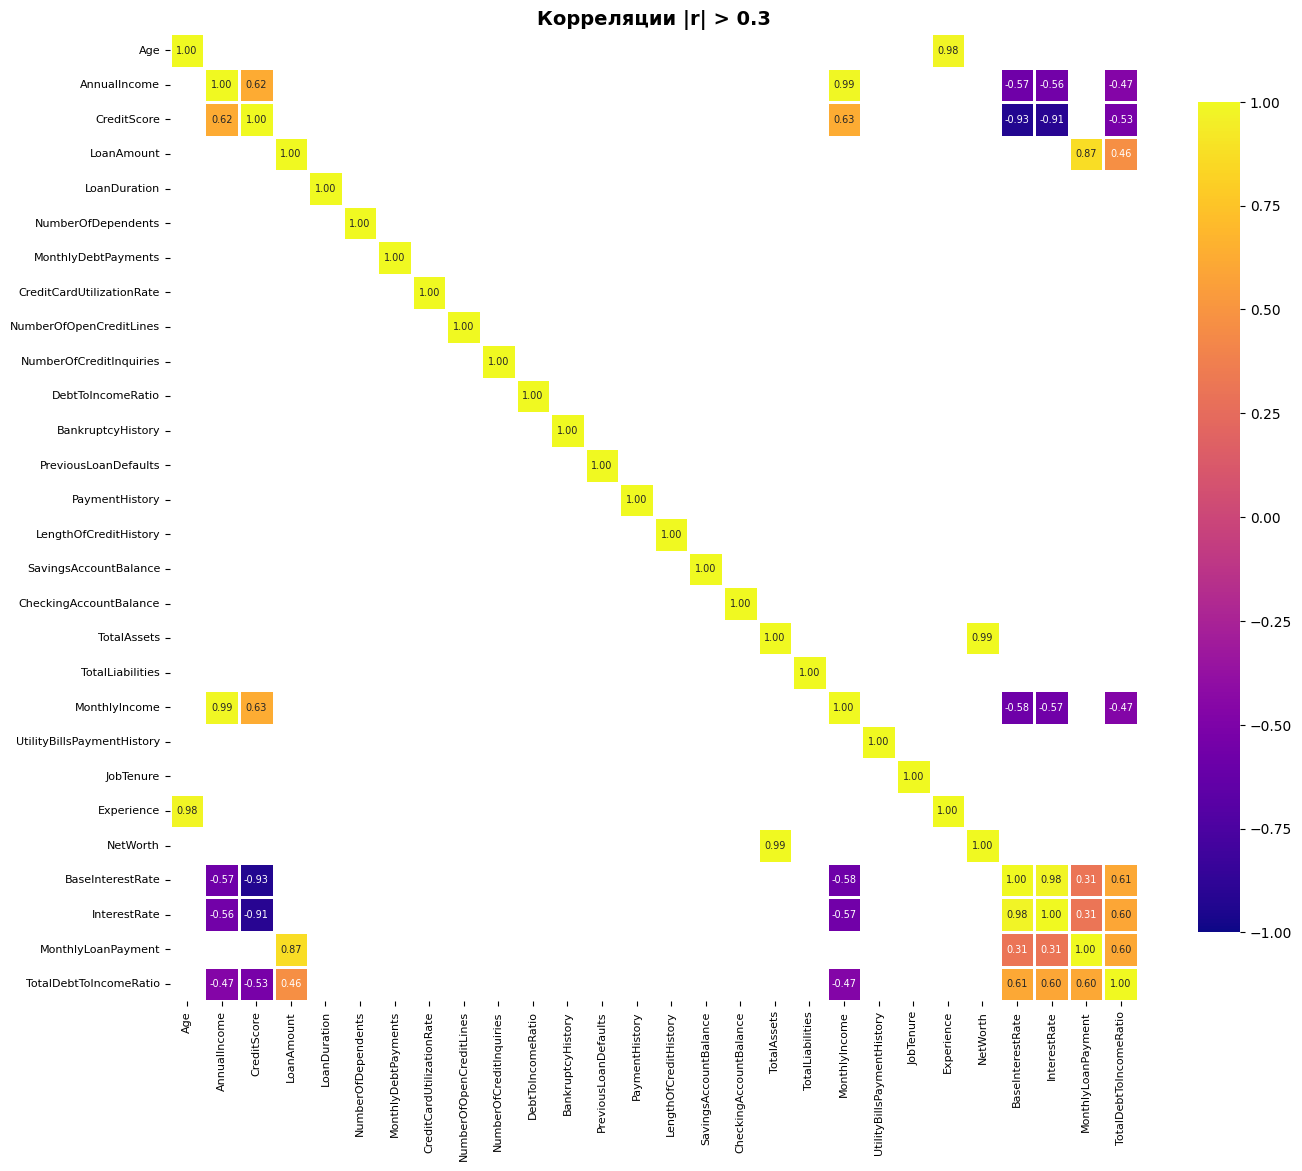

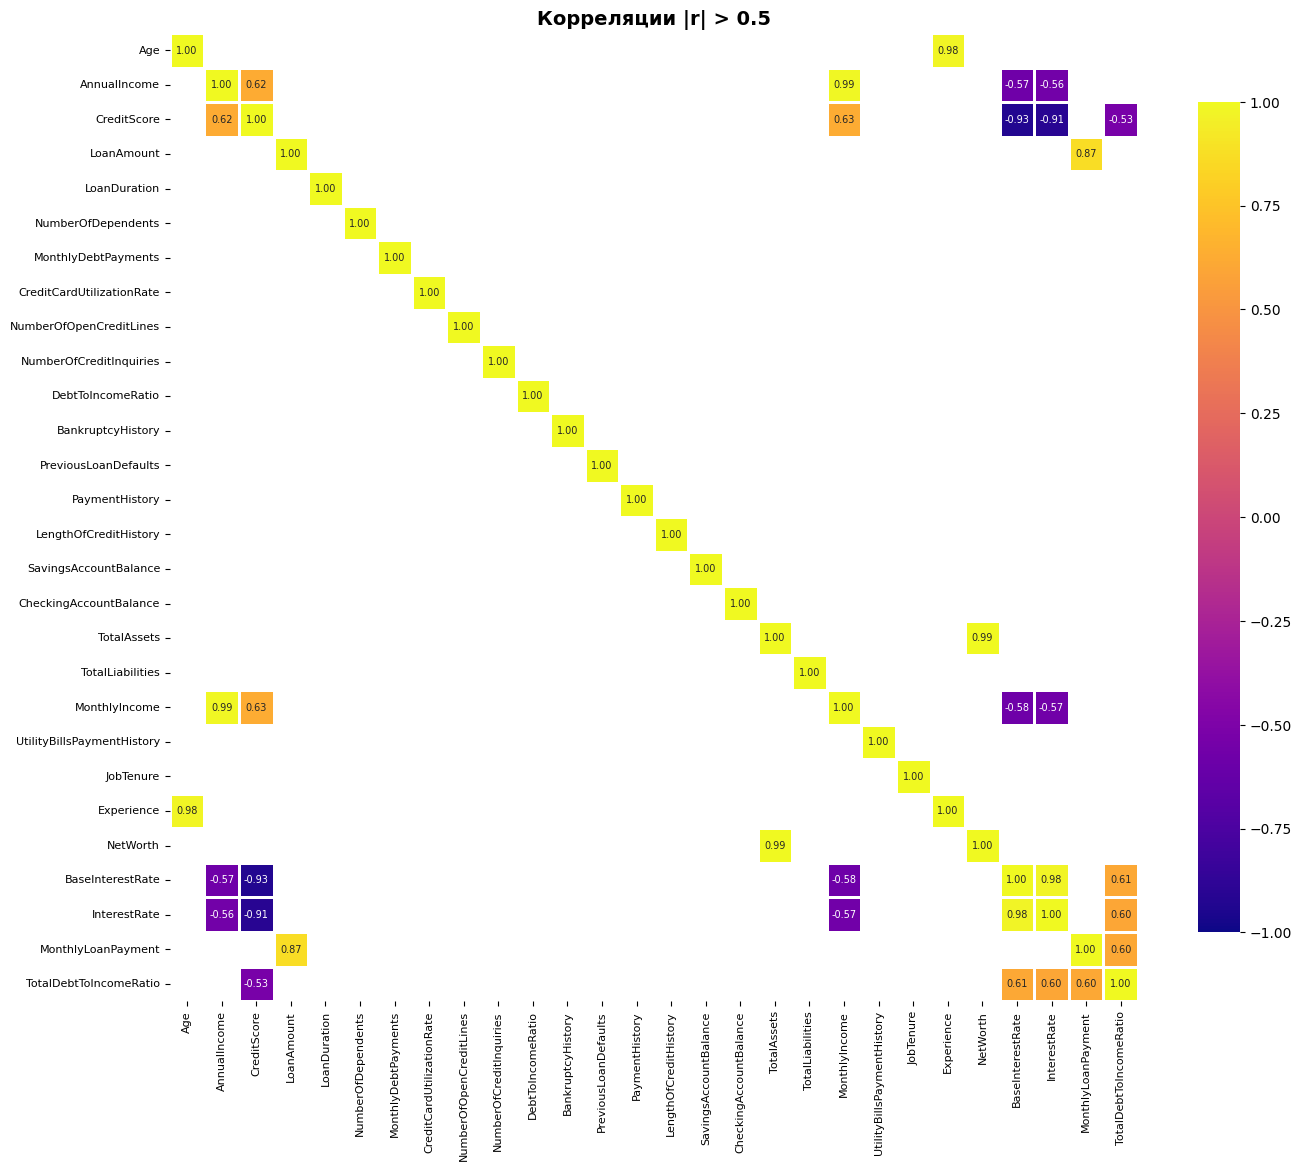

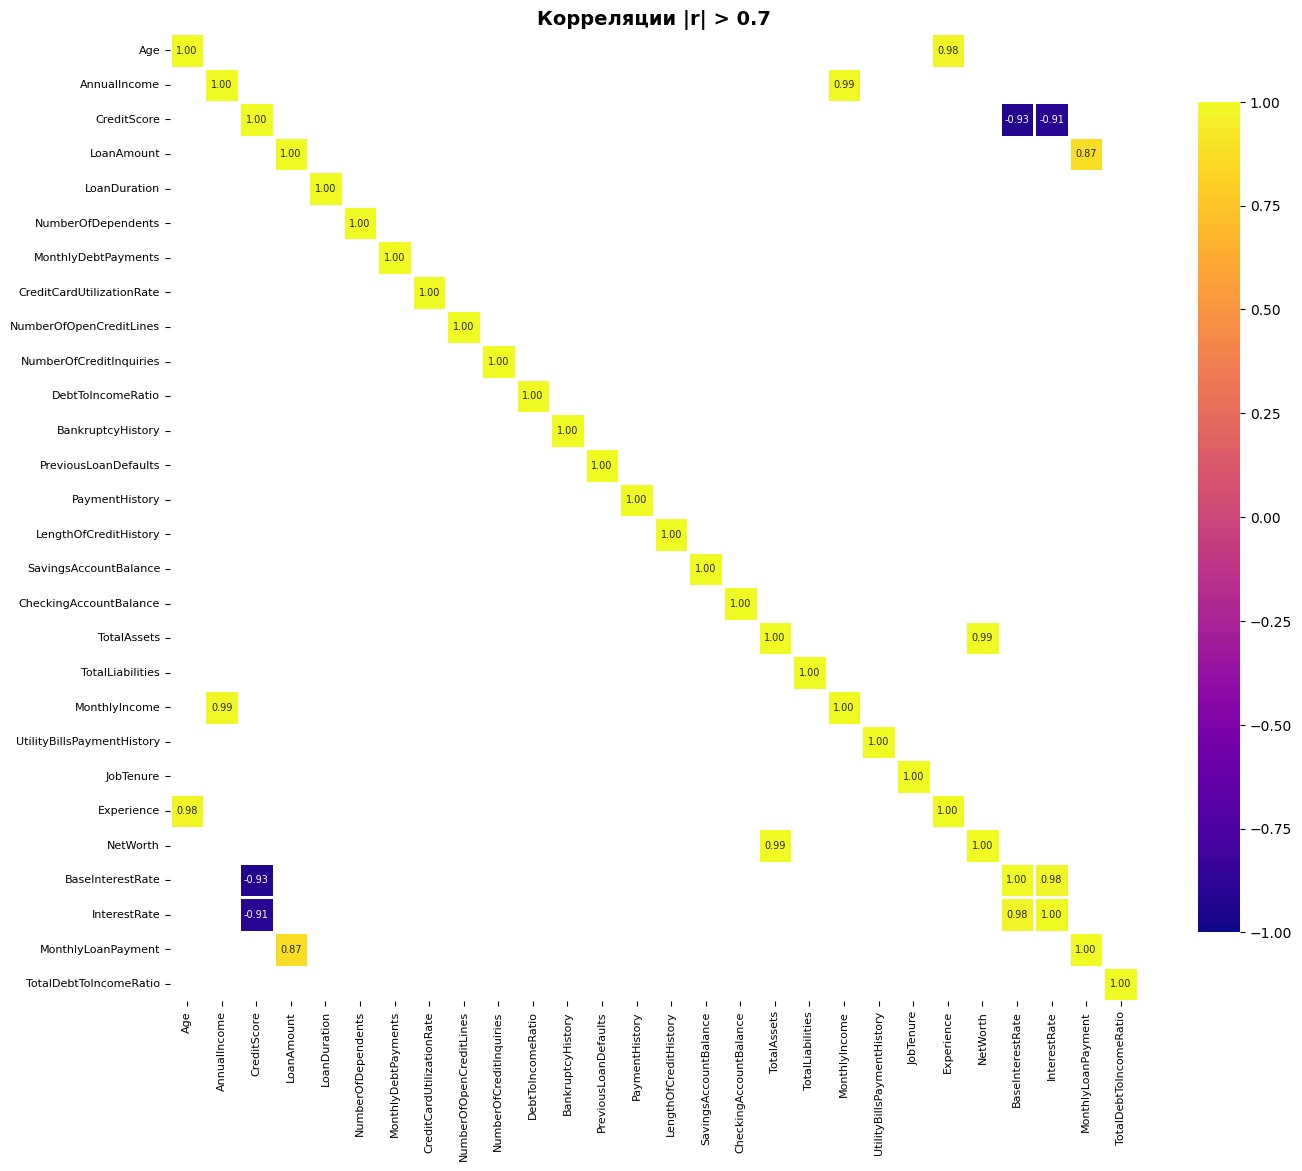

In [40]:
# Анализ целевой переменной
loan_dist = train['LoanApproved'].value_counts().sort_index()
n_total = len(train)

balance_df = pd.DataFrame({
    'Класс': ['Rejected (0)', 'Approved (1)'],
    'Количество': [loan_dist[0], loan_dist[1]],
    'Процент': [f"{loan_dist[0]/n_total*100:.2f}%", f"{loan_dist[1]/n_total*100:.2f}%"]
})

styled_balance = balance_df.style.set_properties(**{
    'text-align': 'center',
    'color': 'white',
    'background-color': '#333'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
])

display(styled_balance)

imb_ratio = max(loan_dist[0], loan_dist[1]) / min(loan_dist[0], loan_dist[1])
print(f"Соотношение классов: {imb_ratio:.2f}:1")

if imb_ratio > 1.5:
    print("Обнаружен дисбаланс классов.")
else:
    print("Существенного дисбаланса классов не наблюдается.")

# Визуализация баланса
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#2a2a2a')

axes[0].bar(['Rejected (0)', 'Approved (1)'], loan_dist.values,
            color=['lightcoral', 'lightgreen'], edgecolor='white', linewidth=2)
axes[0].set_ylabel('Количество', fontsize=12, color='white')
axes[0].set_title('Распределение классов', fontweight='bold', fontsize=14, color='white')
axes[0].grid(True, alpha=0.3, color='gray', axis='y')
axes[0].set_facecolor('#333')
axes[0].tick_params(colors='white')
for i, v in enumerate(loan_dist.values):
    axes[0].text(i, v + 50, f'{v}\n({v/n_total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, color='white', fontweight='bold')

axes[1].pie(loan_dist.values, labels=['Rejected (0)', 'Approved (1)'],
            autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'],
            startangle=90, textprops={'fontsize': 12, 'color': 'white', 'fontweight': 'bold'})
axes[1].set_title('Доля классов', fontweight='bold', fontsize=14, color='white')

plt.tight_layout()
plt.show()

# Chi-square тест для категориальных признаков
categorical_cols = ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose',
                    'EmploymentStatus', 'EducationLevel']

chi_results = []
for col in categorical_cols:
    if col in train.columns:
        cont_table = pd.crosstab(train[col], train['LoanApproved'])
        chi2, pval, dof, expected = chi2_contingency(cont_table)

        n = cont_table.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(cont_table.shape) - 1)))

        chi_results.append({
            'Признак': col,
            'Chi2': chi2,
            'P-value': pval,
            'Cramers_V': cramers_v,
            'Связь': 'Есть' if pval < 0.05 else 'Нет'
        })

chi_df = pd.DataFrame(chi_results).sort_values('Cramers_V', ascending=False)

styled_chi = chi_df.style.format({
    'Chi2': '{:.2f}',
    'P-value': '{:.2e}',
    'Cramers_V': '{:.4f}'
}).set_properties(**{
    'text-align': 'center',
    'color': 'white',
    'background-color': '#333'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
])

display(styled_chi)

# Числовые признаки
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'LoanApproved']

# Point-Biserial корреляция
corr_dict = {}
for col in num_cols:
    # Убираем строки где есть NaN либо в признаке, либо в таргете
    valid_mask = train[col].notna() & train['LoanApproved'].notna()
    clean_data = train.loc[valid_mask, col]
    target = train.loc[valid_mask, 'LoanApproved']
    
    # Проверяем что данных достаточно и есть вариативность
    if len(clean_data) > 0 and clean_data.std() > 0 and target.nunique() > 1:
        r, pval = pointbiserialr(target, clean_data)
        corr_dict[col] = {'correlation': r, 'p_value': pval}
    else:
        corr_dict[col] = {'correlation': 0.0, 'p_value': 1.0}

corr_sorted = dict(sorted(
    corr_dict.items(),
    key=lambda x: abs(x[1]['correlation']),
    reverse=True
))

corr_df = pd.DataFrame([
    {'Признак': col, 'Корреляция': stats['correlation'], 'P-value': stats['p_value']}
    for col, stats in corr_sorted.items()
])

styled_corr = corr_df.style.format({
    'Корреляция': '{:.4f}',
    'P-value': '{:.2e}'
}).set_properties(**{
    'text-align': 'center',
    'color': 'white',
    'background-color': '#333'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
])

print("Point-Biserial корреляция признаков с LoanApproved:")
display(styled_corr)

print(f"Максимальная положительная корреляция: {corr_df.iloc[0]['Корреляция']:.4f} ({corr_df.iloc[0]['Признак']})")
print(f"Средняя абсолютная корреляция: {corr_df['Корреляция'].abs().mean():.4f}")
print(f"Медианная абсолютная корреляция: {corr_df['Корреляция'].abs().median():.4f}")

# Категоризация по силе связи
strong_pos = corr_df[(corr_df['Корреляция'] > 0.1)]
moderate_pos = corr_df[(corr_df['Корреляция'] > 0.05) & (corr_df['Корреляция'] <= 0.1)]
weak_pos = corr_df[(corr_df['Корреляция'] > 0) & (corr_df['Корреляция'] <= 0.05)]
weak_neg = corr_df[(corr_df['Корреляция'] < 0) & (corr_df['Корреляция'] >= -0.05)]
moderate_neg = corr_df[(corr_df['Корреляция'] < -0.05) & (corr_df['Корреляция'] >= -0.1)]
strong_neg = corr_df[corr_df['Корреляция'] < -0.1]

print("Распределение силы корреляций:")
print(f"  Сильная положительная (>0.1):       {len(strong_pos)} признаков")
print(f"  Умеренная положительная (0.05-0.1): {len(moderate_pos)} признаков")
print(f"  Слабая положительная (0-0.05):      {len(weak_pos)} признаков")
print(f"  Слабая отрицательная (-0.05-0):     {len(weak_neg)} признаков")
print(f"  Умеренная отрицательная (-0.1--0.05): {len(moderate_neg)} признаков")
print(f"  Сильная отрицательная (<-0.1):      {len(strong_neg)} признаков")

if len(strong_pos) > 0:
    print("Признаки с сильной положительной корреляцией (>0.1):")
    styled_strong = strong_pos.style.format({
        'Корреляция': '{:.4f}',
        'P-value': '{:.2e}'
    }).set_properties(**{
        'text-align': 'center',
        'color': 'white',
        'background-color': '#333'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
        {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
    ])
    display(styled_strong)

if len(strong_neg) > 0:
    print("Признаки с сильной отрицательной корреляцией (<-0.1):")
    styled_neg = strong_neg.style.format({
        'Корреляция': '{:.4f}',
        'P-value': '{:.2e}'
    }).set_properties(**{
        'text-align': 'center',
        'color': 'white',
        'background-color': '#333'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
        {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
    ])
    display(styled_neg)

# Визуализация boxplot для признаков с наибольшей по модулю корреляцией
top_feats = corr_df.head(16)['Признак'].values

fig, axes = plt.subplots(4, 4, figsize=(20, 16), facecolor='#2a2a2a')
axes = axes.ravel()

for idx, feat in enumerate(top_feats):
    d0 = train[train['LoanApproved'] == 0][feat].dropna()
    d1 = train[train['LoanApproved'] == 1][feat].dropna()

    bp = axes[idx].boxplot([d0, d1],
                           labels=['Rejected (0)', 'Approved (1)'],
                           patch_artist=True)

    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightgreen')

    r_val = corr_dict[feat]['correlation']
    p_val = corr_dict[feat]['p_value']

    axes[idx].set_ylabel(feat, fontsize=9, color='white')
    axes[idx].set_title(f'{feat}\nr={r_val:.4f}, p={p_val:.2e}',
                        fontweight='bold', fontsize=10, color='white')
    axes[idx].grid(True, alpha=0.3, color='gray', axis='y')
    axes[idx].set_facecolor('#333')
    axes[idx].tick_params(colors='white')
    axes[idx].spines['bottom'].set_color('white')
    axes[idx].spines['left'].set_color('white')
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

fig.suptitle('Топ-16 признаков: распределение по классам LoanApproved',
             fontsize=16, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

# Анализ мультиколлинеарности
corr_matrix = train[num_cols].corr()

pairs = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        r_val = corr_matrix.loc[num_cols[i], num_cols[j]]
        pairs.append({
            'Feature_1': num_cols[i],
            'Feature_2': num_cols[j],
            'Correlation': r_val,
            'Abs_Correlation': abs(r_val)
        })

pairs_df = pd.DataFrame(pairs)

styled_pairs = pairs_df.sort_values('Abs_Correlation', ascending=False).head(20).style.format({
    'Correlation': '{:.4f}',
    'Abs_Correlation': '{:.4f}'
}).set_properties(**{
    'text-align': 'center',
    'color': 'white',
    'background-color': '#333'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
])
print("Топ-20 парных корреляций:")
display(styled_pairs)

print(f"Общее количество уникальных пар признаков: {len(pairs_df)}")

bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0.0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5',
          '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

pairs_df['Corr_Range'] = pd.cut(pairs_df['Abs_Correlation'], bins=bins, labels=labels)
distr = pairs_df['Corr_Range'].value_counts().sort_index()

print("Распределение парных корреляций по диапазонам:")
for range_label, cnt in distr.items():
    pct = (cnt / len(pairs_df)) * 100
    print(f"  |r| в диапазоне {range_label}: {cnt:4d} пар ({pct:5.2f}%)")

print("Статистика по абсолютным значениям корреляций:")
print(f"  Минимальная абсолютная корреляция: {pairs_df['Abs_Correlation'].min():.6f}")
print(f"  Максимальная абсолютная корреляция: {pairs_df['Abs_Correlation'].max():.6f}")
print(f"  Средняя абсолютная корреляция:     {pairs_df['Abs_Correlation'].mean():.6f}")
print(f"  Медианная абсолютная корреляция:   {pairs_df['Abs_Correlation'].median():.6f}")
print(f"  Стандартное отклонение:            {pairs_df['Abs_Correlation'].std():.6f}")

print("Пары с высокой корреляцией:")
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for thr in thresholds:
    cnt = (pairs_df['Abs_Correlation'] > thr).sum()
    pct = (cnt / len(pairs_df)) * 100
    print(f"  |r| > {thr:.1f}: {cnt:4d} пар ({pct:5.2f}%)")

# Статистика по признакам
feat_stats = []
for feat in num_cols:
    feat_corrs = corr_matrix[feat].drop(feat, errors='ignore').abs()

    feat_stats.append({
        'Feature': feat,
        'Mean_Abs_Corr': feat_corrs.mean(),
        'Median_Abs_Corr': feat_corrs.median(),
        'Max_Abs_Corr': feat_corrs.max(),
        'Min_Abs_Corr': feat_corrs.min(),
        'Corr_>0.3': (feat_corrs > 0.3).sum(),
        'Corr_>0.5': (feat_corrs > 0.5).sum(),
        'Corr_>0.7': (feat_corrs > 0.7).sum(),
        'LoanApproved_Corr': corr_dict[feat]['correlation'] if feat in corr_dict else 0
    })

stats_df = pd.DataFrame(feat_stats).sort_values('Max_Abs_Corr', ascending=False)
styled_stats = stats_df.style.format({
    'Mean_Abs_Corr': '{:.4f}',
    'Median_Abs_Corr': '{:.4f}',
    'Max_Abs_Corr': '{:.4f}',
    'Min_Abs_Corr': '{:.4f}',
    'Corr_>0.3': '{:d}',
    'Corr_>0.5': '{:d}',
    'Corr_>0.7': '{:d}',
    'LoanApproved_Corr': '{:.4f}'
}).set_properties(**{
    'text-align': 'center',
    'color': 'white',
    'background-color': '#333'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
])
print("Статистика корреляций по признакам:")
display(styled_stats)

print("Топ-10 признаков с наибольшей средней корреляцией с другими:")
top_mean_corr = stats_df.nlargest(10, 'Mean_Abs_Corr')
styled_top = top_mean_corr[['Feature', 'Mean_Abs_Corr', 'Max_Abs_Corr', 'LoanApproved_Corr']].style.format({
    'Mean_Abs_Corr': '{:.4f}',
    'Max_Abs_Corr': '{:.4f}',
    'LoanApproved_Corr': '{:.4f}'
}).set_properties(**{
    'text-align': 'center',
    'color': 'white',
    'background-color': '#333'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
])
display(styled_top)

print("Признаки с наибольшим количеством высоких корреляций:")
multicoll = stats_df[stats_df['Corr_>0.5'] > 0].sort_values('Corr_>0.5', ascending=False)
if len(multicoll) > 0:
    styled_multi = multicoll[['Feature', 'Corr_>0.3', 'Corr_>0.5', 'Corr_>0.7', 'Max_Abs_Corr']].style.format({
        'Corr_>0.3': '{:d}',
        'Corr_>0.5': '{:d}',
        'Corr_>0.7': '{:d}',
        'Max_Abs_Corr': '{:.4f}'
    }).set_properties(**{
        'text-align': 'center',
        'color': 'white',
        'background-color': '#333'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
        {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
    ])
    display(styled_multi)
else:
    print("Признаков с корреляциями выше 0.5 не найдено.")

# Тепловые карты корреляций
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='plasma', center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1,
            square=True)
plt.title('Корреляционная матрица признаков', fontweight='bold', fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

viz_thresholds = [0.3, 0.5, 0.7]
for thr in viz_thresholds:
    mask = np.abs(corr_matrix) < thr
    corr_masked = corr_matrix.copy()
    corr_masked[mask] = np.nan

    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_masked, annot=True, fmt='.2f', cmap='plasma', center=0,
                linewidths=1, cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1,
                square=True, annot_kws={"size": 7})
    plt.title(f'Корреляции |r| > {thr}', fontweight='bold', fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()


Доход (MonthlyIncome r≈0.75, AnnualIncome r≈0.74) и CreditScore (r≈0.58) положительно влияют на одобрение. Процентные ставки (BaseInterestRate r≈-0.61, InterestRate r≈-0.60) и TotalDebtToIncomeRatio (r≈-0.48) — отрицательно. Большинство остальных признаков имеют слабую связь с таргетом (медианная корреляция ≈0.038).



Обнаружено 6 пар с корреляцией >0.9:
- TotalAssets–NetWorth (r≈0.994)
- AnnualIncome–MonthlyIncome (r≈0.985)
- Age–Experience (r≈0.983)
- BaseInterestRate–InterestRate (r≈0.975)
- CreditScore отрицательно коррелирует со ставками (r≈-0.93)

Остальные 92% пар имеют корреляцию <0.1, что позволяет адресно удалять только дублирующие признаки.



TotalDebtToIncomeRatio и процентные ставки имеют наибольшее число значимых связей (6-7 корреляций >0.3). Признаки кредитной истории и балансы счетов остаются независимыми источниками информации.

## Анализ аномалий и выбросов



Анализируем 28 числовых признаков

Топ-20 признаков по проценту выбросов (метод IQR):


,Feature,Total_Count,Outliers_IQR,Outliers_IQR_Pct,Outliers_Zscore,Outliers_Zscore_Pct
23,NetWorth,9986,1234,12.36,137,1.37
17,TotalAssets,9986,1140,11.42,141,1.41
18,TotalLiabilities,10487,1161,11.07,118,1.13
12,PreviousLoanDefaults,10487,1011,9.64,1011,9.64
27,TotalDebtToIncomeRatio,10487,934,8.91,178,1.70
15,SavingsAccountBalance,10487,911,8.69,176,1.68
16,CheckingAccountBalance,9986,821,8.22,160,1.60
26,MonthlyLoanPayment,10487,779,7.43,194,1.85
3,LoanAmount,9986,628,6.29,175,1.75
6,MonthlyDebtPayments,9986,617,6.18,189,1.89



Признаков с >5% выбросов (IQR): 11

Признаки, требующие особого внимания:


,Feature,Outliers_IQR_Pct,Min,Max,Mean,Median
23,NetWorth,12.36,1004.00,11261170.00,154238.13,27429.50
17,TotalAssets,11.42,892.00,11289459.00,183047.61,60543.50
18,TotalLiabilities,11.07,78.00,8997054.00,68816.96,22625.00
12,PreviousLoanDefaults,9.64,0.00,1.00,0.10,0.00
27,TotalDebtToIncomeRatio,8.91,0.01,24.38,0.52,0.18
15,SavingsAccountBalance,8.69,31.00,222556.00,5484.59,2961.00
16,CheckingAccountBalance,8.22,16.00,109245.00,1988.49,1122.50
26,MonthlyLoanPayment,7.43,30.01,29634.81,1075.62,684.88
3,LoanAmount,6.29,1063.00,418997.00,29874.22,21828.50
6,MonthlyDebtPayments,6.18,13.00,10879.00,546.46,398.00



Общая статистика по выбросам:
  Средний % выбросов (IQR):    3.85%
  Медианный % выбросов (IQR):  1.18%
  Максимальный % выбросов:     12.36% (NetWorth)
  Минимальный % выбросов:      0.00%


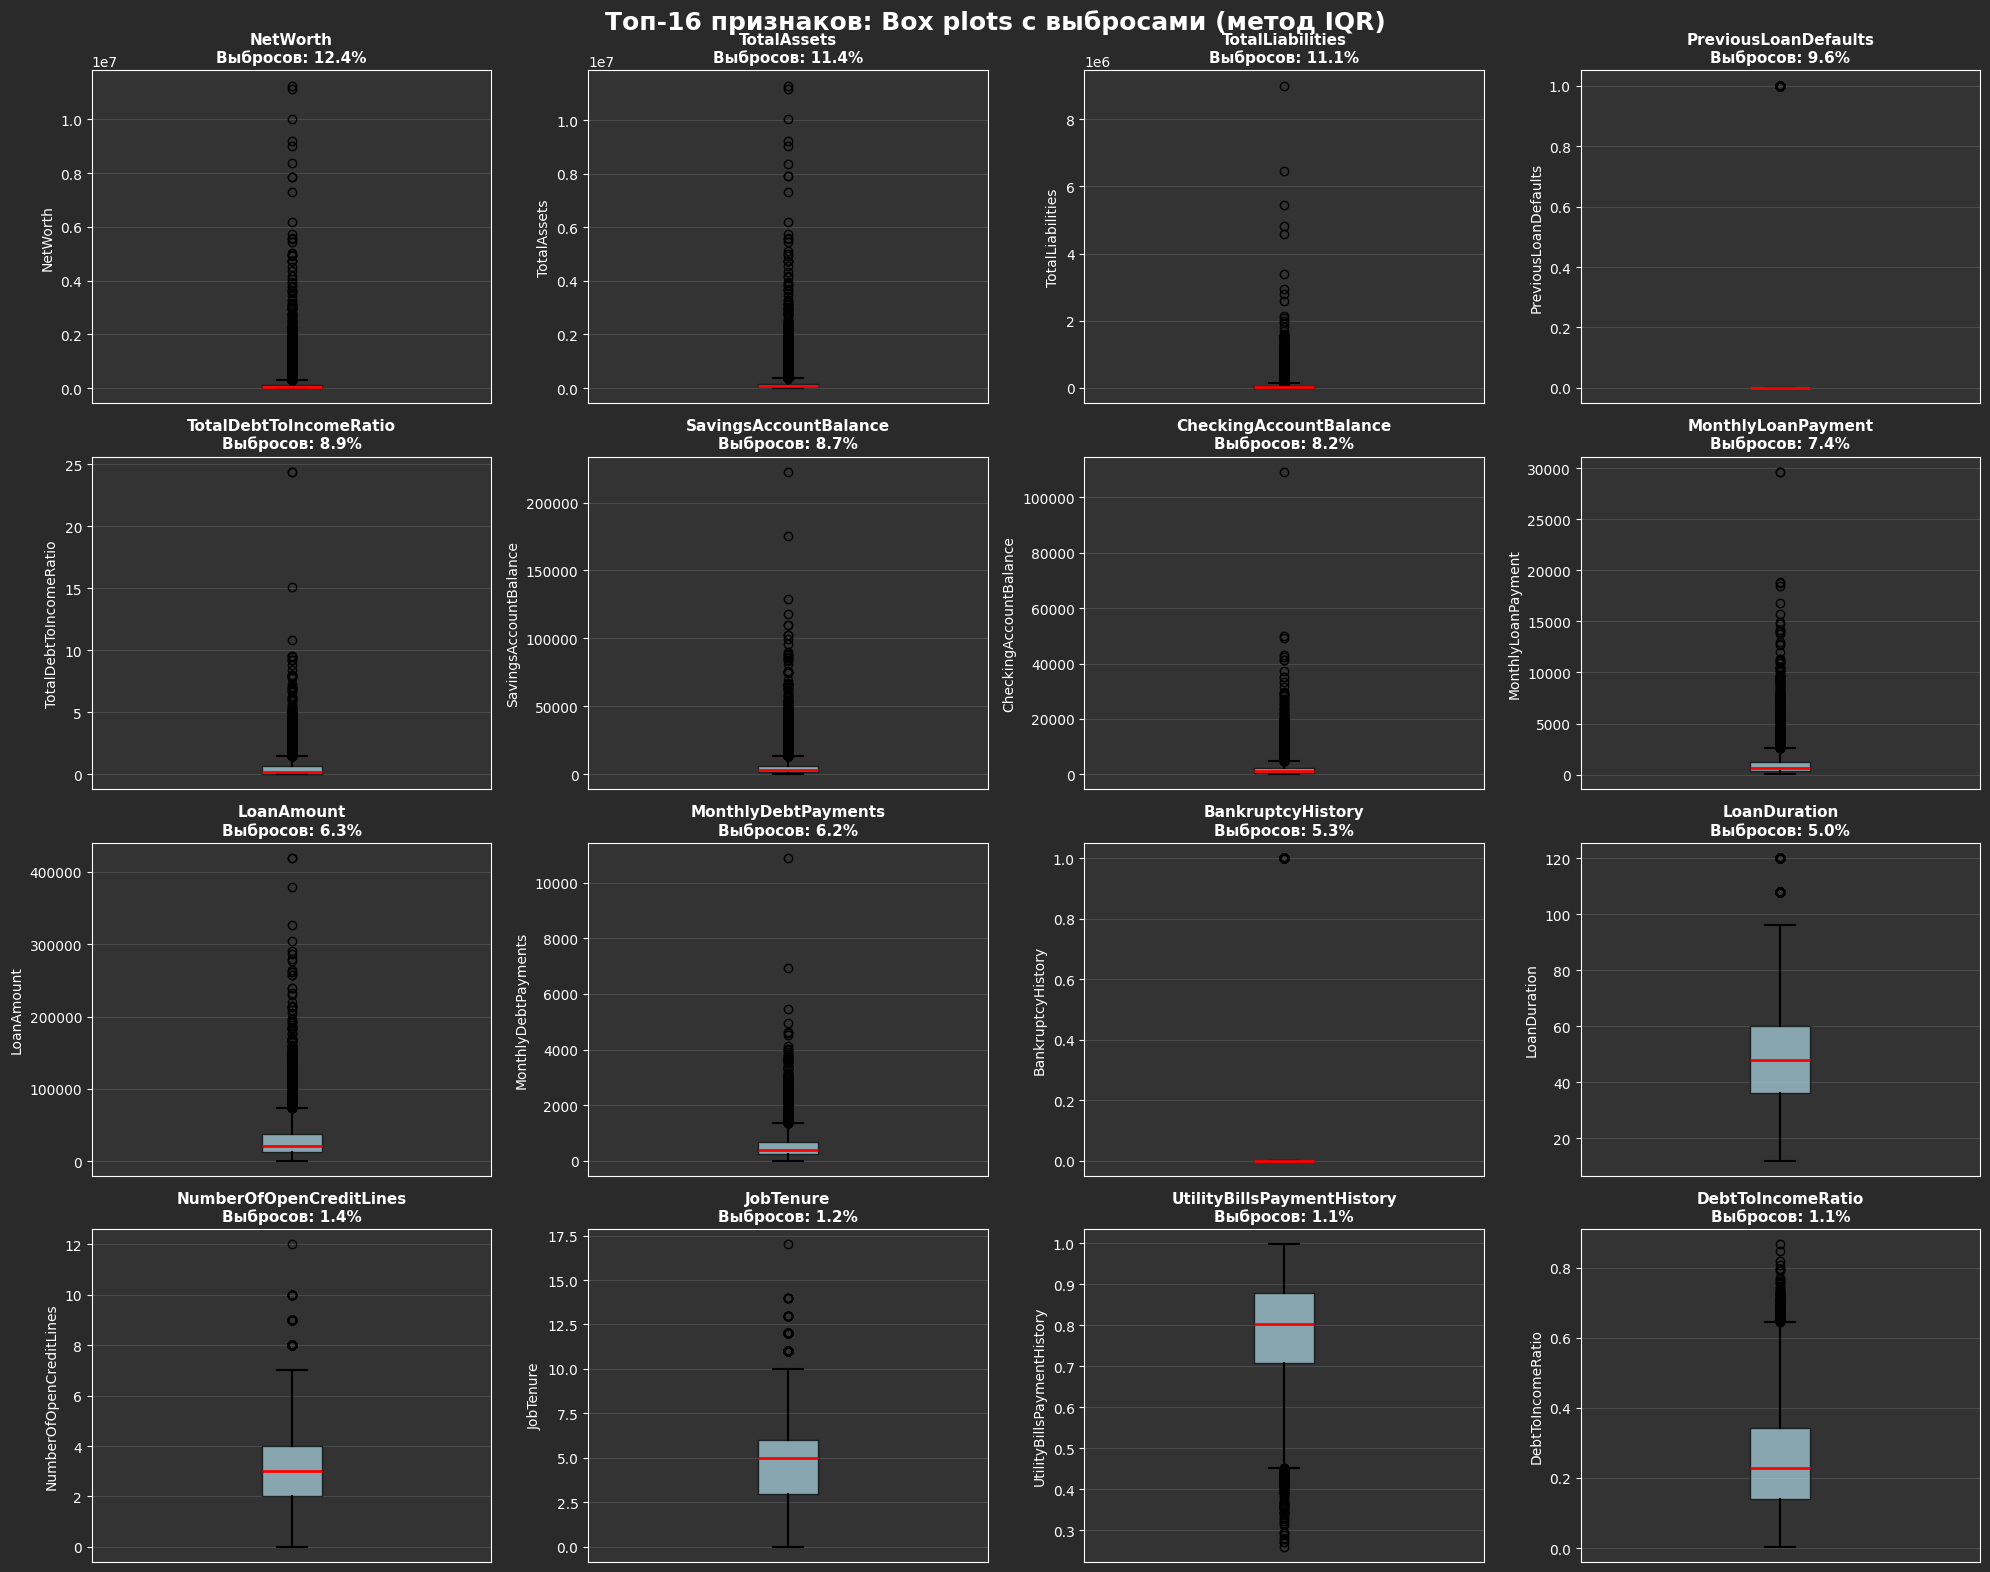

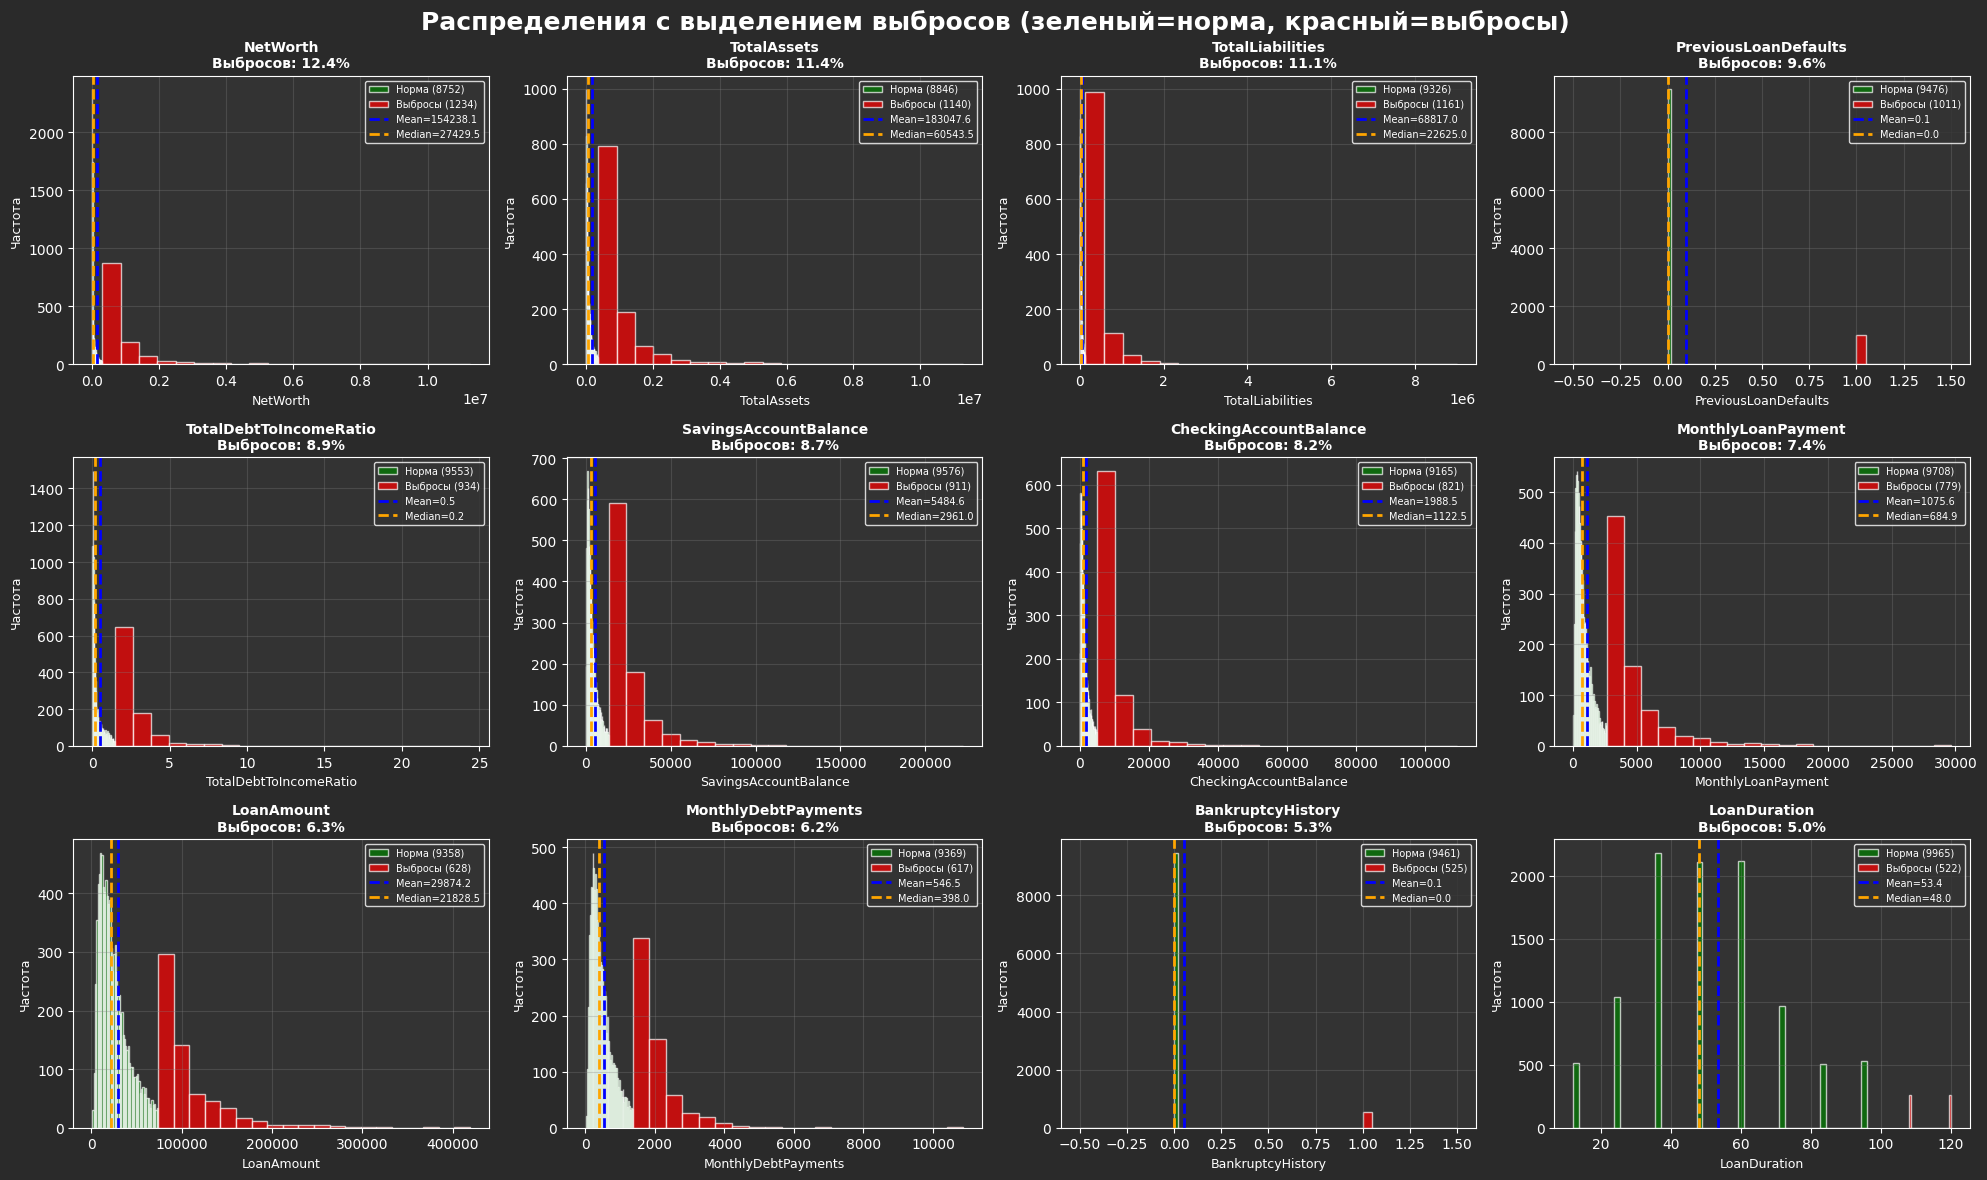

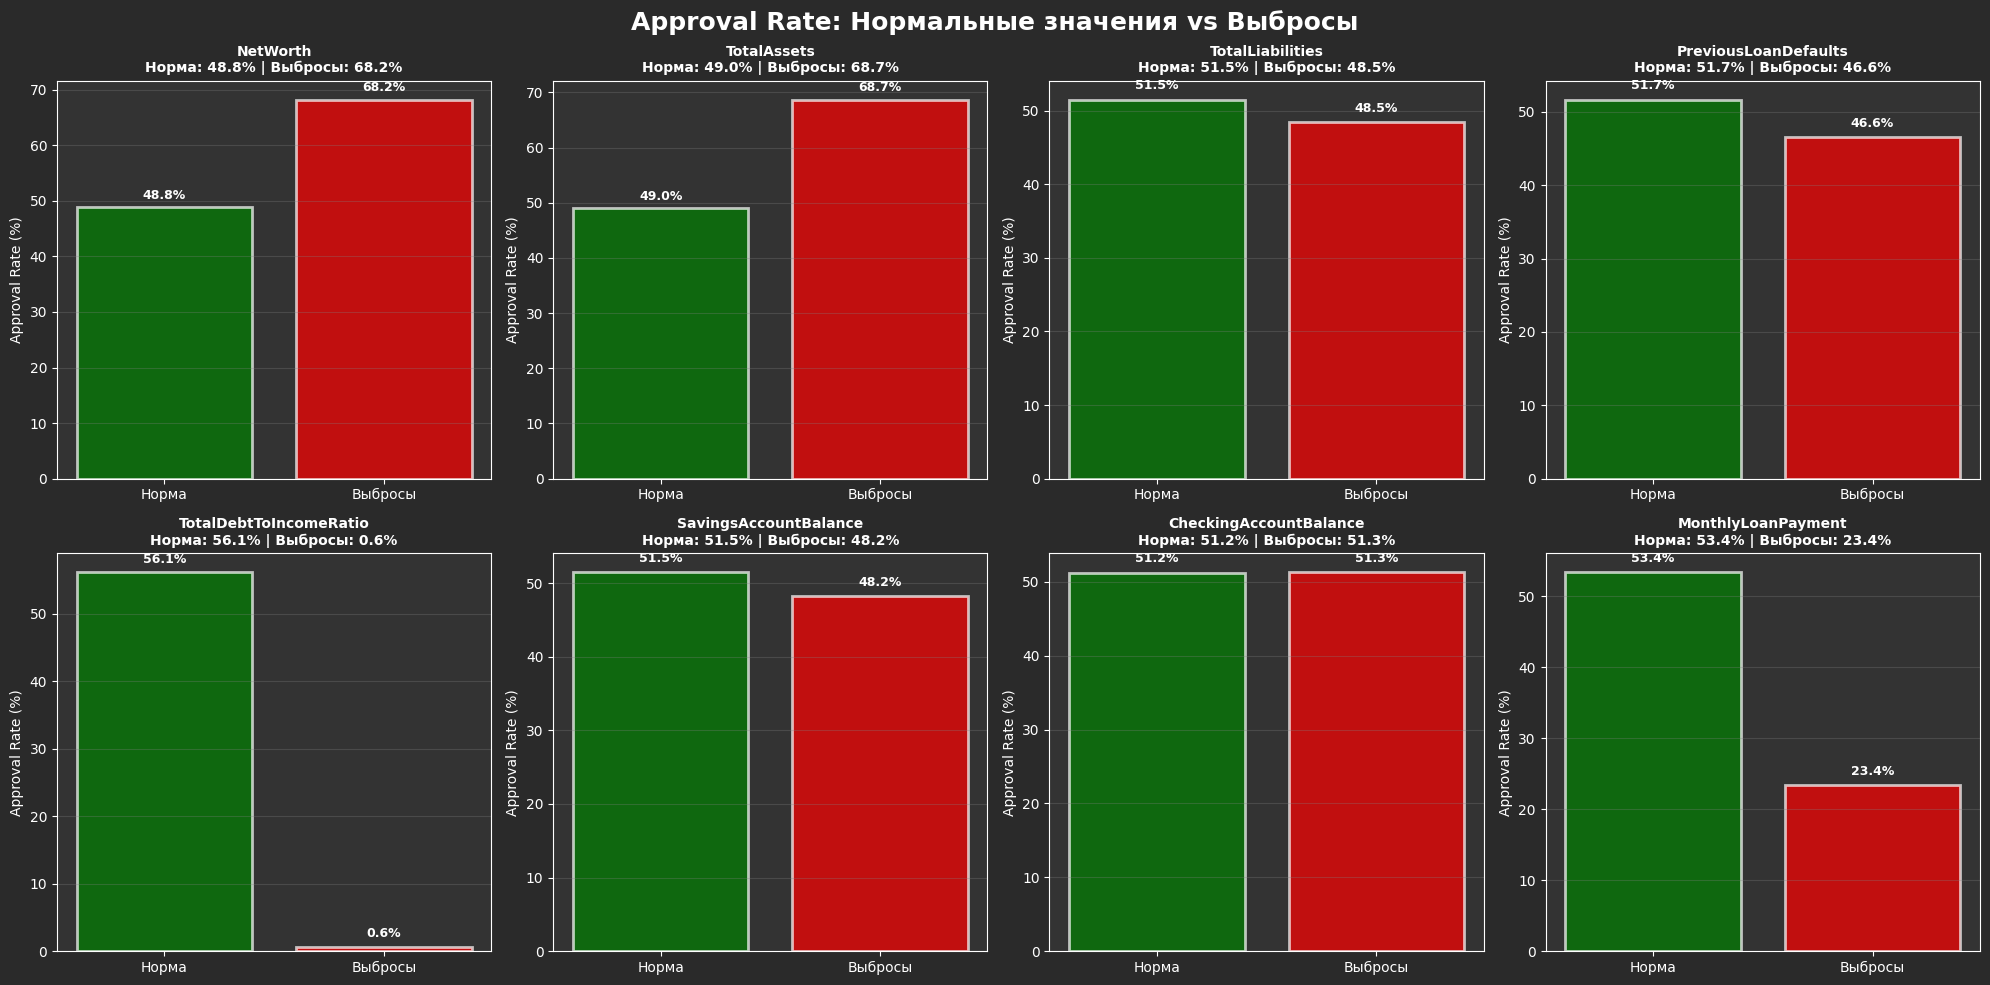


Статистика Approval Rate для нормальных значений и выбросов:


,Feature,Normal_Approval_%,Outlier_Approval_%,Difference,Outlier_Count
4,TotalDebtToIncomeRatio,56.12,0.64,-55.48,934
7,MonthlyLoanPayment,53.41,23.36,-30.05,779
1,TotalAssets,48.98,68.68,+19.70,1140
0,NetWorth,48.83,68.23,+19.40,1234
3,PreviousLoanDefaults,51.67,46.59,-5.08,1011
5,SavingsAccountBalance,51.46,48.19,-3.27,911
2,TotalLiabilities,51.51,48.49,-3.02,1161
6,CheckingAccountBalance,51.23,51.28,+0.05,821


In [41]:
# Отбираем только числовые признаки
numeric_features = [col for col in train.select_dtypes(include=[np.number]).columns 
                    if col != 'LoanApproved']

outlier_analysis = []

for feature in numeric_features:
    data = train[feature].dropna()
    
    if len(data) == 0:
        continue
    
    # Метод IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]
    outlier_pct_iqr = (len(outliers_iqr) / len(data)) * 100
    
    # Метод Z-score
    z_scores = np.abs(stats.zscore(data))
    outliers_z = data[z_scores > 3]
    outlier_pct_z = (len(outliers_z) / len(data)) * 100
    
    outlier_analysis.append({
        'Feature': feature,
        'Total_Count': len(data),
        'Outliers_IQR': len(outliers_iqr),
        'Outliers_IQR_Pct': outlier_pct_iqr,
        'Outliers_Zscore': len(outliers_z),
        'Outliers_Zscore_Pct': outlier_pct_z,
        'Min': data.min(),
        'Q1': Q1,
        'Median': data.median(),
        'Q3': Q3,
        'Max': data.max(),
        'IQR': IQR,
        'Mean': data.mean(),
        'Std': data.std()
    })

outlier_df = pd.DataFrame(outlier_analysis).sort_values('Outliers_IQR_Pct', ascending=False)

print(f"\nАнализируем {len(numeric_features)} числовых признаков")
print("\nТоп-20 признаков по проценту выбросов (метод IQR):")

styled_outlier = outlier_df[['Feature', 'Total_Count', 'Outliers_IQR', 'Outliers_IQR_Pct', 
                              'Outliers_Zscore', 'Outliers_Zscore_Pct']].head(20).style.format({
    'Total_Count': '{:.0f}',
    'Outliers_IQR': '{:.0f}',
    'Outliers_IQR_Pct': '{:.2f}',
    'Outliers_Zscore': '{:.0f}',
    'Outliers_Zscore_Pct': '{:.2f}'
}).set_properties(**{
    'text-align': 'center',
    'color': 'white',
    'background-color': '#333'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
])
display(styled_outlier)

# Статистика по выбросам
high_outliers = outlier_df[outlier_df['Outliers_IQR_Pct'] > 5]
print(f"\nПризнаков с >5% выбросов (IQR): {len(high_outliers)}")

if len(high_outliers) > 0:
    print("\nПризнаки, требующие особого внимания:")
    styled_high = high_outliers[['Feature', 'Outliers_IQR_Pct', 'Min', 'Max', 'Mean', 'Median']].style.format({
        'Outliers_IQR_Pct': '{:.2f}',
        'Min': '{:.2f}',
        'Max': '{:.2f}',
        'Mean': '{:.2f}',
        'Median': '{:.2f}'
    }).set_properties(**{
        'text-align': 'center',
        'color': 'white',
        'background-color': '#333'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
        {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
    ])
    display(styled_high)

print(f"\nОбщая статистика по выбросам:")
print(f"  Средний % выбросов (IQR):    {outlier_df['Outliers_IQR_Pct'].mean():.2f}%")
print(f"  Медианный % выбросов (IQR):  {outlier_df['Outliers_IQR_Pct'].median():.2f}%")
print(f"  Максимальный % выбросов:     {outlier_df['Outliers_IQR_Pct'].max():.2f}% ({outlier_df.iloc[0]['Feature']})")
print(f"  Минимальный % выбросов:      {outlier_df['Outliers_IQR_Pct'].min():.2f}%")

# Визуализация выбросов - box plots для топ-16 признаков
top_outlier_features = outlier_df.head(16)['Feature'].values
fig, axes = plt.subplots(4, 4, figsize=(20, 16), facecolor='#2a2a2a')
axes = axes.ravel()

for idx, feature in enumerate(top_outlier_features):
    data = train[feature].dropna()
    outlier_info = outlier_df[outlier_df['Feature'] == feature].iloc[0]
    
    bp = axes[idx].boxplot(data, vert=True, patch_artist=True,
                           boxprops=dict(facecolor='lightblue', alpha=0.7),
                           medianprops=dict(color='red', linewidth=2),
                           whiskerprops=dict(linewidth=1.5),
                           capprops=dict(linewidth=1.5))
    
    axes[idx].set_ylabel(feature, fontsize=10, color='white')
    axes[idx].set_title(f'{feature}\nВыбросов: {outlier_info["Outliers_IQR_Pct"]:.1f}%',
                        fontweight='bold', fontsize=11, color='white')
    axes[idx].grid(True, alpha=0.3, color='gray', axis='y')
    axes[idx].set_xticks([])
    axes[idx].set_facecolor('#333')
    axes[idx].tick_params(colors='white')
    for spine in axes[idx].spines.values():
        spine.set_color('white')

fig.suptitle('Топ-16 признаков: Box plots с выбросами (метод IQR)', 
             fontsize=18, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

# Гистограммы распределений с выделением выбросов
top_12_outliers = outlier_df.head(12)['Feature'].values
fig, axes = plt.subplots(3, 4, figsize=(20, 12), facecolor='#2a2a2a')
axes = axes.ravel()

for idx, feature in enumerate(top_12_outliers):
    data = train[feature].dropna()
    outlier_info = outlier_df[outlier_df['Feature'] == feature].iloc[0]
    
    Q1 = outlier_info['Q1']
    Q3 = outlier_info['Q3']
    IQR = outlier_info['IQR']
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    normal_data = data[(data >= lower_bound) & (data <= upper_bound)]
    outlier_data = data[(data < lower_bound) | (data > upper_bound)]
    
    axes[idx].hist(normal_data, bins=50, alpha=0.7, color='green', 
                   label=f'Норма ({len(normal_data)})', edgecolor='white')
    axes[idx].hist(outlier_data, bins=20, alpha=0.7, color='red', 
                   label=f'Выбросы ({len(outlier_data)})', edgecolor='white')
    axes[idx].axvline(data.mean(), color='blue', linestyle='--', linewidth=2, 
                     label=f'Mean={data.mean():.1f}')
    axes[idx].axvline(data.median(), color='orange', linestyle='--', linewidth=2, 
                     label=f'Median={data.median():.1f}')
    
    axes[idx].set_xlabel(feature, fontsize=9, color='white')
    axes[idx].set_ylabel('Частота', fontsize=9, color='white')
    axes[idx].set_title(f'{feature}\nВыбросов: {outlier_info["Outliers_IQR_Pct"]:.1f}%',
                        fontweight='bold', fontsize=10, color='white')
    axes[idx].legend(facecolor='#333', edgecolor='white', labelcolor='white', fontsize=7)
    axes[idx].grid(True, alpha=0.3, color='gray')
    axes[idx].set_facecolor('#333')
    axes[idx].tick_params(colors='white')
    for spine in axes[idx].spines.values():
        spine.set_color('white')

fig.suptitle('Распределения с выделением выбросов (зеленый=норма, красный=выбросы)', 
             fontsize=18, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

# Анализ влияния выбросов на Approval Rate
top_8_outliers = outlier_df.head(8)['Feature'].values

fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor='#2a2a2a')
axes = axes.ravel()

for idx, feature in enumerate(top_8_outliers):
    outlier_info = outlier_df[outlier_df['Feature'] == feature].iloc[0]
    
    Q1 = outlier_info['Q1']
    Q3 = outlier_info['Q3']
    IQR = outlier_info['IQR']
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    train_copy = train[[feature, 'LoanApproved']].dropna()
    train_copy['is_outlier'] = ((train_copy[feature] < lower_bound) | 
                                 (train_copy[feature] > upper_bound)).astype(int)
    
    # Approval Rate для нормальных и выбросов
    normal_approval = train_copy[train_copy['is_outlier'] == 0]['LoanApproved'].mean() * 100
    outlier_approval = train_copy[train_copy['is_outlier'] == 1]['LoanApproved'].mean() * 100
    
    categories = ['Норма', 'Выбросы']
    values = [normal_approval, outlier_approval]
    colors_bar = ['green', 'red']
    
    bars = axes[idx].bar(categories, values, color=colors_bar, edgecolor='white', linewidth=2, alpha=0.7)
    axes[idx].set_ylabel('Approval Rate (%)', fontsize=10, color='white')
    axes[idx].set_title(f'{feature}\nНорма: {normal_approval:.1f}% | Выбросы: {outlier_approval:.1f}%',
                        fontweight='bold', fontsize=10, color='white')
    axes[idx].grid(True, alpha=0.3, color='gray', axis='y')
    axes[idx].set_facecolor('#333')
    axes[idx].tick_params(colors='white')
    for spine in axes[idx].spines.values():
        spine.set_color('white')
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 1,
                      f'{val:.1f}%', ha='center', va='bottom', 
                      fontsize=9, color='white', fontweight='bold')

fig.suptitle('Approval Rate: Нормальные значения vs Выбросы', 
             fontsize=18, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

# Таблица со статистикой влияния выбросов
print("\nСтатистика Approval Rate для нормальных значений и выбросов:")
outlier_impact = []
for feature in top_8_outliers:
    outlier_info = outlier_df[outlier_df['Feature'] == feature].iloc[0]
    
    Q1 = outlier_info['Q1']
    Q3 = outlier_info['Q3']
    IQR = outlier_info['IQR']
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    train_copy = train[[feature, 'LoanApproved']].dropna()
    train_copy['is_outlier'] = ((train_copy[feature] < lower_bound) | 
                                 (train_copy[feature] > upper_bound)).astype(int)
    
    normal_approval = train_copy[train_copy['is_outlier'] == 0]['LoanApproved'].mean() * 100
    outlier_approval = train_copy[train_copy['is_outlier'] == 1]['LoanApproved'].mean() * 100
    diff = outlier_approval - normal_approval
    
    outlier_impact.append({
        'Feature': feature,
        'Normal_Approval_%': normal_approval,
        'Outlier_Approval_%': outlier_approval,
        'Difference': diff,
        'Outlier_Count': int(outlier_info['Outliers_IQR'])
    })

outlier_impact_df = pd.DataFrame(outlier_impact).sort_values('Difference', key=abs, ascending=False)

styled_impact = outlier_impact_df.style.format({
    'Normal_Approval_%': '{:.2f}',
    'Outlier_Approval_%': '{:.2f}',
    'Difference': '{:+.2f}',
    'Outlier_Count': '{:.0f}'
}).set_properties(**{
    'text-align': 'center',
    'color': 'white',
    'background-color': '#333'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
])
display(styled_impact)


# Чистка от выбросов

In [42]:
train = pd.read_csv('train_c.csv')
test = pd.read_csv('test_c.csv')

print("ПОЛНАЯ ПРЕПРОЦЕССИНГ ДЛЯ БУСТИНГОВЫХ МОДЕЛЕЙ")
print(f"Исходные размеры: Train {train.shape}, Test {test.shape}")

# Функция заполнения пропусков
def fill_missing_values(df, is_train=True, stats=None):
    '''Заполнение пропусков в данных'''
    df_filled = df.copy()
    
    print("\nЭТАП 1: ЗАПОЛНЕНИЕ ПРОПУСКОВ")
    
    # Проверяем пропуски
    missing = df_filled.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) > 0:
        print(f"\nПропуски найдены в {len(missing)} столбцах:")
        for col, count in missing.items():
            pct = 100 * count / len(df_filled)
            print(f"  {col}: {count} ({pct:.1f}%)")
    else:
        print("\nПропусков не найдено!")
        return df_filled, {}
    
    # Если это train, считаем статистику
    if is_train:
        stats = {}
        
        # Числовые признаки
        print("\nЗаполнение числовых признаков медианой")
        
        numeric_cols = df_filled.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if df_filled[col].isnull().sum() > 0:
                median_val = df_filled[col].median()
                stats[col] = {'type': 'median', 'value': median_val}
                df_filled[col].fillna(median_val, inplace=True)
                print(f"  {col}: заполнено медианой = {median_val:.2f}")
        
        # Категориальные признаки
        print("\nЗаполнение категориальных признаков модой")
        
        categorical_cols = df_filled.select_dtypes(exclude=[np.number]).columns
        for col in categorical_cols:
            if df_filled[col].isnull().sum() > 0:
                mode_val = df_filled[col].mode()[0] if len(df_filled[col].mode()) > 0 else 'Unknown'
                stats[col] = {'type': 'mode', 'value': mode_val}
                df_filled[col].fillna(mode_val, inplace=True)
                print(f"  {col}: заполнено модой = '{mode_val}'")
    
    # Если это test, используем статистику из train
    else:
        print("\nПрименяем статистику из train к test")
        
        for col, stat_info in stats.items():
            if col in df_filled.columns and df_filled[col].isnull().sum() > 0:
                df_filled[col].fillna(stat_info['value'], inplace=True)
                print(f"  {col}: заполнено {stat_info['type']} = {stat_info['value']}")
    
    # Проверка после заполнения
    remaining_nulls = df_filled.isnull().sum().sum()
    print(f"\nОставшихся пропусков: {remaining_nulls}")
    
    return df_filled, stats

# Функция подготовки данных для бустинга
def prepare_for_boosting(df):
    '''Подготовка данных для бустинга'''
    df_boost = df.copy()
    
    print("\nЭТАП 2: ОБРАБОТКА ВЫБРОСОВ + FEATURE ENGINEERING")
    
    # Умеренная винсоризация только для самых экстремальных выбросов
    moderate_outliers = ['TotalDebtToIncomeRatio', 'SavingsAccountBalance', 
                        'CheckingAccountBalance', 'MonthlyLoanPayment',
                        'LoanAmount', 'MonthlyDebtPayments']
    
    print("\nПрименяем легкую винсоризацию (0.5%-99.5%)")
    
    for feat in moderate_outliers:
        if feat in df_boost.columns:
            p05 = df_boost[feat].quantile(0.005)
            p995 = df_boost[feat].quantile(0.995)
            df_boost[feat] = df_boost[feat].clip(lower=p05, upper=p995)
            print(f"  {feat}: обрезка [{p05:.2f}, {p995:.2f}]")
    
    # Feature engineering
    print("\nСоздаем новые признаки")
    
    # Флаги для критических выбросов
    if 'TotalDebtToIncomeRatio' in df_boost.columns:
        Q3 = df_boost['TotalDebtToIncomeRatio'].quantile(0.75)
        IQR = Q3 - df_boost['TotalDebtToIncomeRatio'].quantile(0.25)
        df_boost['HighDebtRatio_flag'] = (df_boost['TotalDebtToIncomeRatio'] > Q3 + 1.5*IQR).astype(int)
        print("  + HighDebtRatio_flag")
    
    if 'MonthlyLoanPayment' in df_boost.columns:
        Q3 = df_boost['MonthlyLoanPayment'].quantile(0.75)
        IQR = Q3 - df_boost['MonthlyLoanPayment'].quantile(0.25)
        df_boost['HighMonthlyPayment_flag'] = (df_boost['MonthlyLoanPayment'] > Q3 + 1.5*IQR).astype(int)
        print("  + HighMonthlyPayment_flag")
    
    # Относительные метрики
    if 'NetWorth' in df_boost.columns and 'TotalAssets' in df_boost.columns:
        df_boost['NetWorth_to_Assets'] = df_boost['NetWorth'] / (df_boost['TotalAssets'] + 1)
        print("  + NetWorth_to_Assets")
    
    if 'TotalLiabilities' in df_boost.columns and 'TotalAssets' in df_boost.columns:
        df_boost['Liabilities_to_Assets'] = df_boost['TotalLiabilities'] / (df_boost['TotalAssets'] + 1)
        print("  + Liabilities_to_Assets")
    
    # Логарифмы для сильно скошенных признаков
    high_skew = ['NetWorth', 'TotalAssets', 'TotalLiabilities']
    print("\nСоздаем логарифмические версии признаков")
    
    for feat in high_skew:
        if feat in df_boost.columns:
            df_boost[f'{feat}_log'] = np.log1p(np.maximum(df_boost[feat], 0))
            print(f"  + {feat}_log")
    
    return df_boost

# Шаг 1: Заполняем пропуски в train
train_filled, fill_stats = fill_missing_values(train, is_train=True)

# Шаг 2: Заполняем пропуски в test (используем статистику из train)
test_filled, _ = fill_missing_values(test, is_train=False, stats=fill_stats)

# Шаг 3: Применяем обработку выбросов и feature engineering к train
print("\nОБРАБОТКА TRAIN")
train_final = prepare_for_boosting(train_filled)

# Шаг 4: Применяем ту же обработку к test
print("\nОБРАБОТКА TEST")
test_final = prepare_for_boosting(test_filled)

# Финальная проверка и сохранение
print("\nФИНАЛЬНАЯ ПРОВЕРКА")

print(f"\nИтоговые размеры:")
print(f"  Train: {train_final.shape}")
print(f"  Test:  {test_final.shape}")

print(f"\nПропуски в train: {train_final.isnull().sum().sum()}")
print(f"Пропуски в test:  {test_final.isnull().sum().sum()}")

# Проверяем целевую переменную
if 'LoanApproved' in train_final.columns:
    print(f"\nЦелевая переменная 'LoanApproved':")
    print(f"  Всего: {len(train_final)}")
    print(f"  NaN: {train_final['LoanApproved'].isna().sum()}")
    print(f"  Распределение:")
    print(train_final['LoanApproved'].value_counts())
    
    # Удаляем строки с NaN в целевой переменной
    if train_final['LoanApproved'].isna().sum() > 0:
        print(f"\nНайдено {train_final['LoanApproved'].isna().sum()} NaN в целевой переменной")
        print("  Удаляем эти строки...")
        train_final = train_final.dropna(subset=['LoanApproved'])
        print(f"  Осталось строк: {len(train_final)}")

# Сохраняем
train_final.to_csv('train_for_boosting.csv', index=False)
test_final.to_csv('test_for_boosting.csv', index=False)




ПОЛНАЯ ПРЕПРОЦЕССИНГ ДЛЯ БУСТИНГОВЫХ МОДЕЛЕЙ
Исходные размеры: Train (11017, 35), Test (5000, 35)

ЭТАП 1: ЗАПОЛНЕНИЕ ПРОПУСКОВ

Пропуски найдены в 35 столбцах:
  TotalAssets: 1031 (9.4%)
  CreditScore: 1031 (9.4%)
  LoanAmount: 1031 (9.4%)
  BaseInterestRate: 1031 (9.4%)
  NetWorth: 1031 (9.4%)
  MonthlyDebtPayments: 1031 (9.4%)
  CheckingAccountBalance: 1031 (9.4%)
  LoanPurpose: 1031 (9.4%)
  BankruptcyHistory: 1031 (9.4%)
  JobTenure: 530 (4.8%)
  TotalLiabilities: 530 (4.8%)
  MonthlyIncome: 530 (4.8%)
  UtilityBillsPaymentHistory: 530 (4.8%)
  ApplicationDate: 530 (4.8%)
  EmploymentStatus: 530 (4.8%)
  EducationLevel: 530 (4.8%)
  InterestRate: 530 (4.8%)
  MonthlyLoanPayment: 530 (4.8%)
  TotalDebtToIncomeRatio: 530 (4.8%)
  Experience: 530 (4.8%)
  PaymentHistory: 530 (4.8%)
  SavingsAccountBalance: 530 (4.8%)
  LengthOfCreditHistory: 530 (4.8%)
  Age: 530 (4.8%)
  PreviousLoanDefaults: 530 (4.8%)
  DebtToIncomeRatio: 530 (4.8%)
  NumberOfCreditInquiries: 530 (4.8%)
  NumberOf

#### Микровывод ApplicationDate не содержит значимой предсказательной силы для RiskScore. ну и на новую переменную тоже

## АНАЛИЗ ВЗАИМОДЕЙСТВИЙ ПРИЗНАКОВ

АНАЛИЗ РАСПРЕДЕЛЕНИЙ ВСЕХ ПРИЗНАКОВ
Датасет: (11017, 42)

Числовых признаков: 35
Категориальных признаков: 6

ГИСТОГРАММЫ ЧИСЛОВЫХ ПРИЗНАКОВ


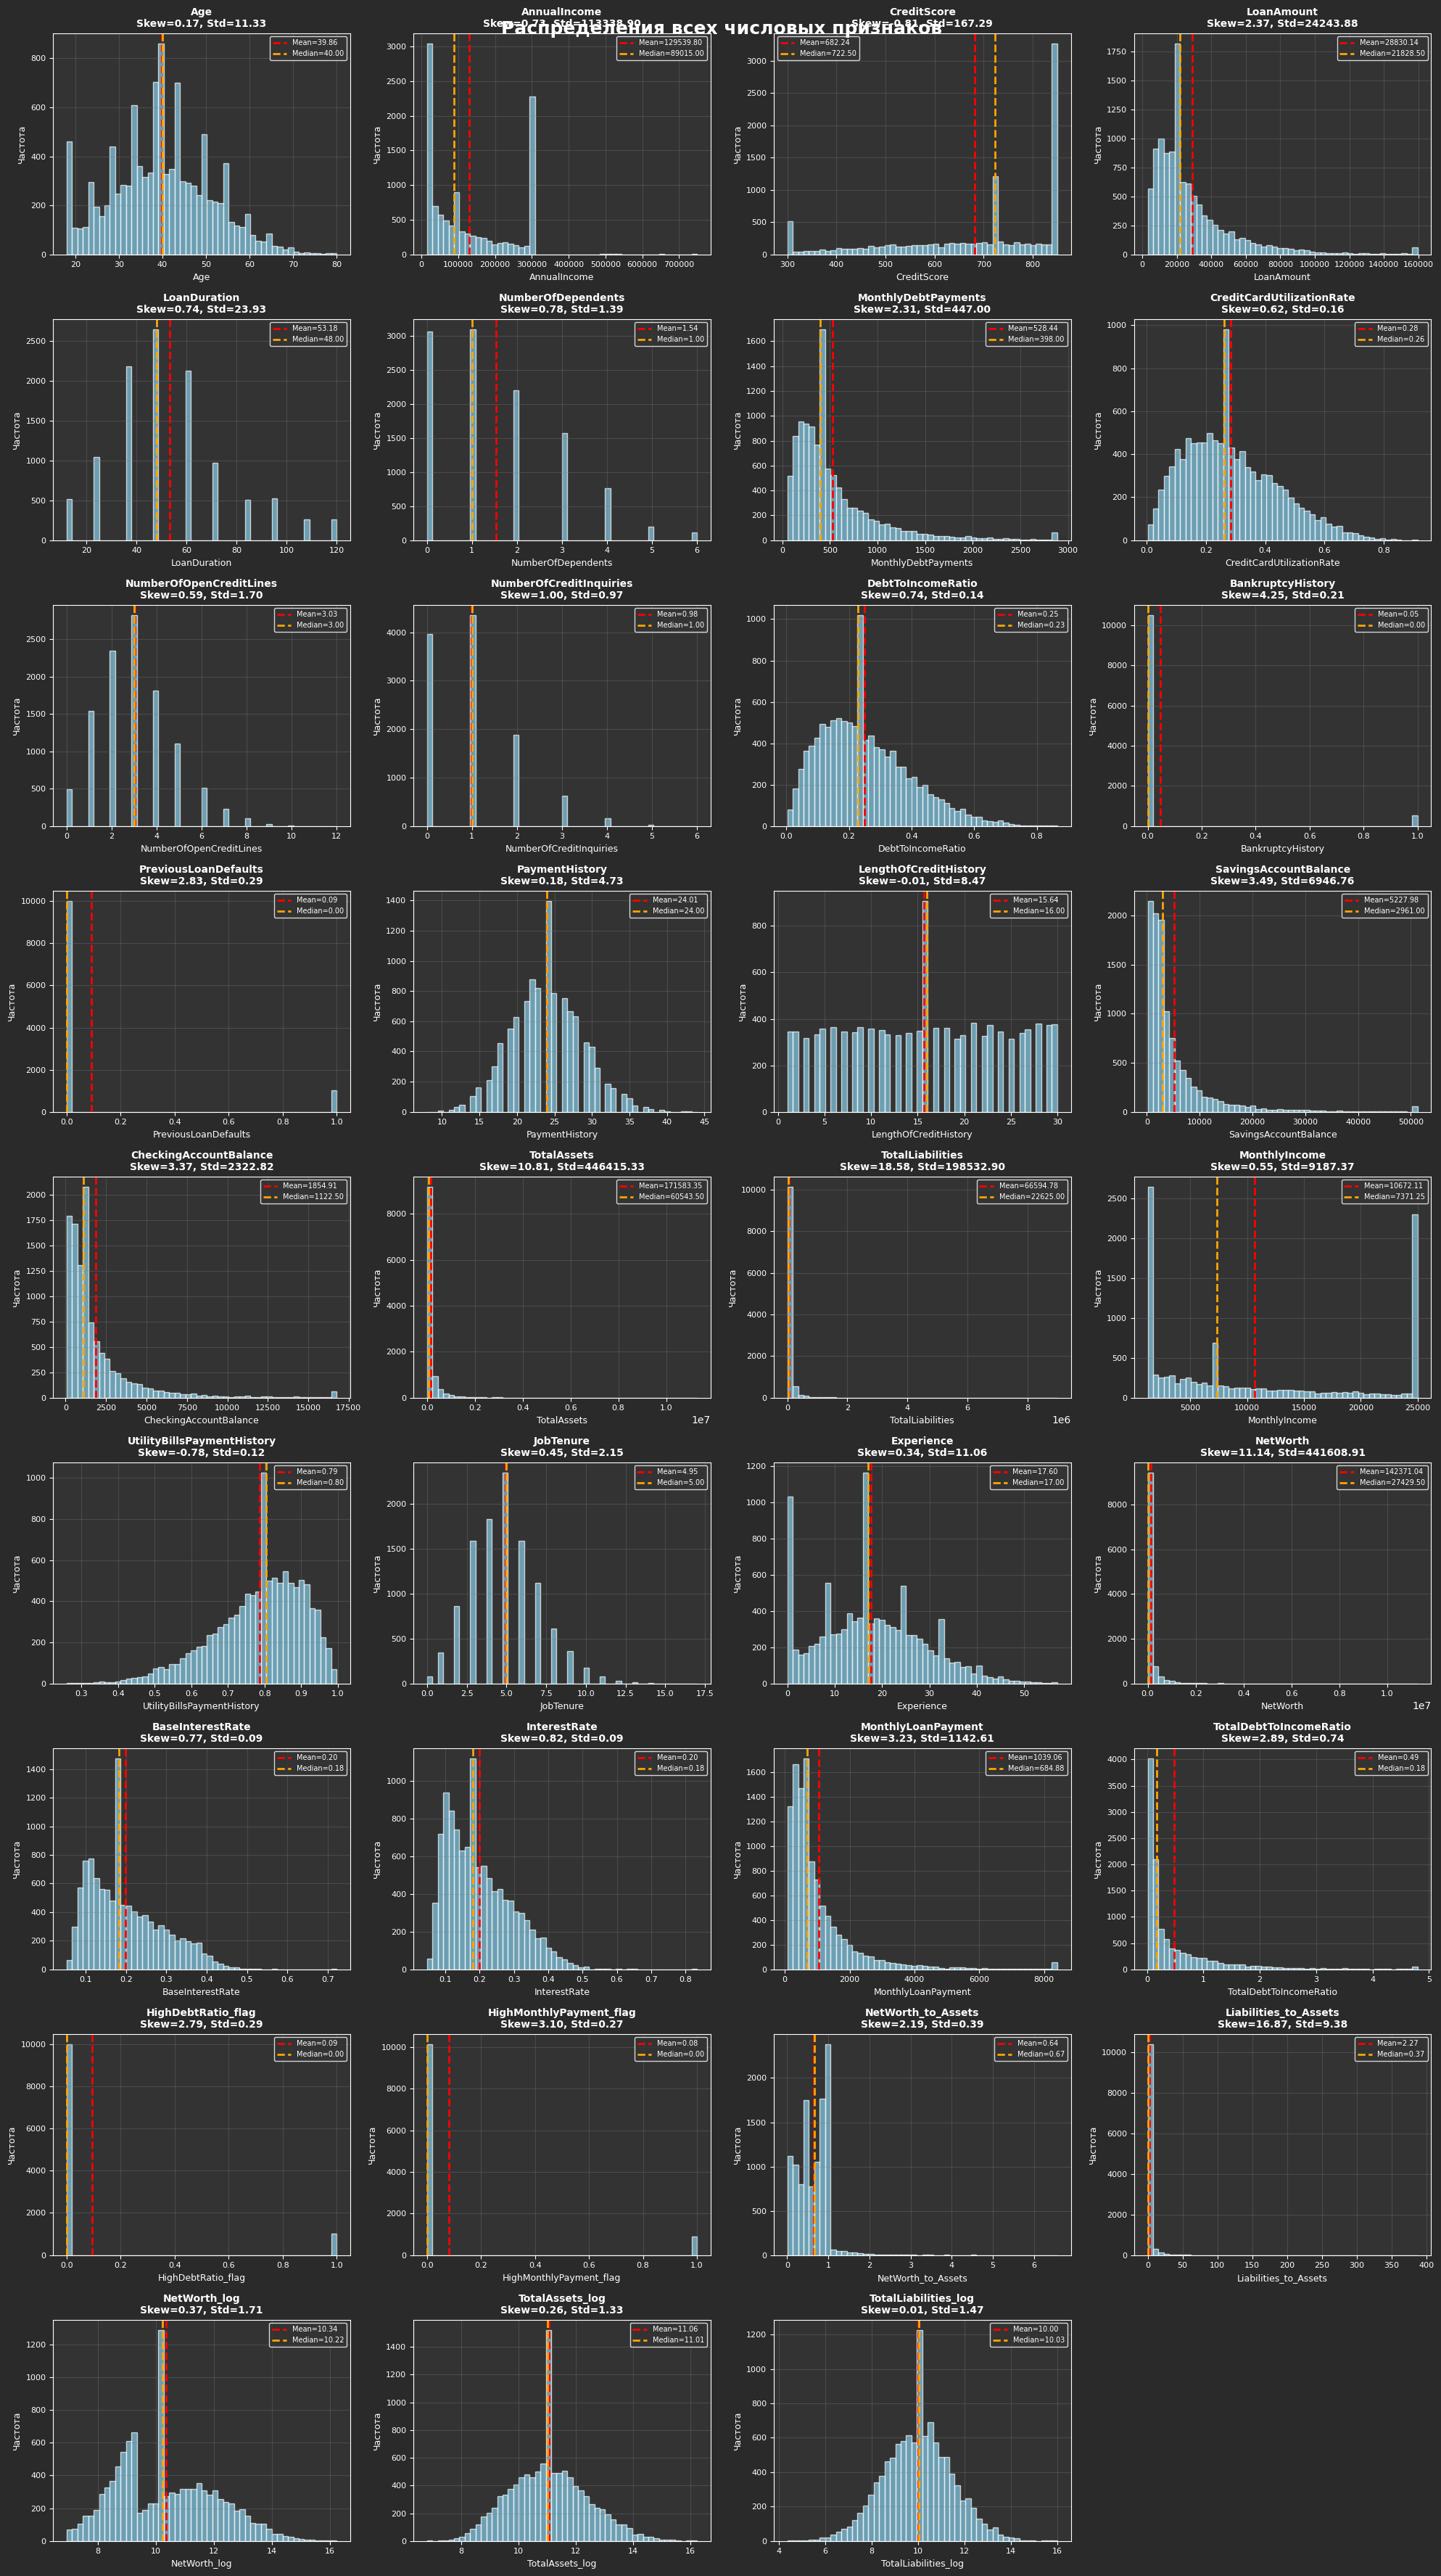


BOX PLOTS ЧИСЛОВЫХ ПРИЗНАКОВ


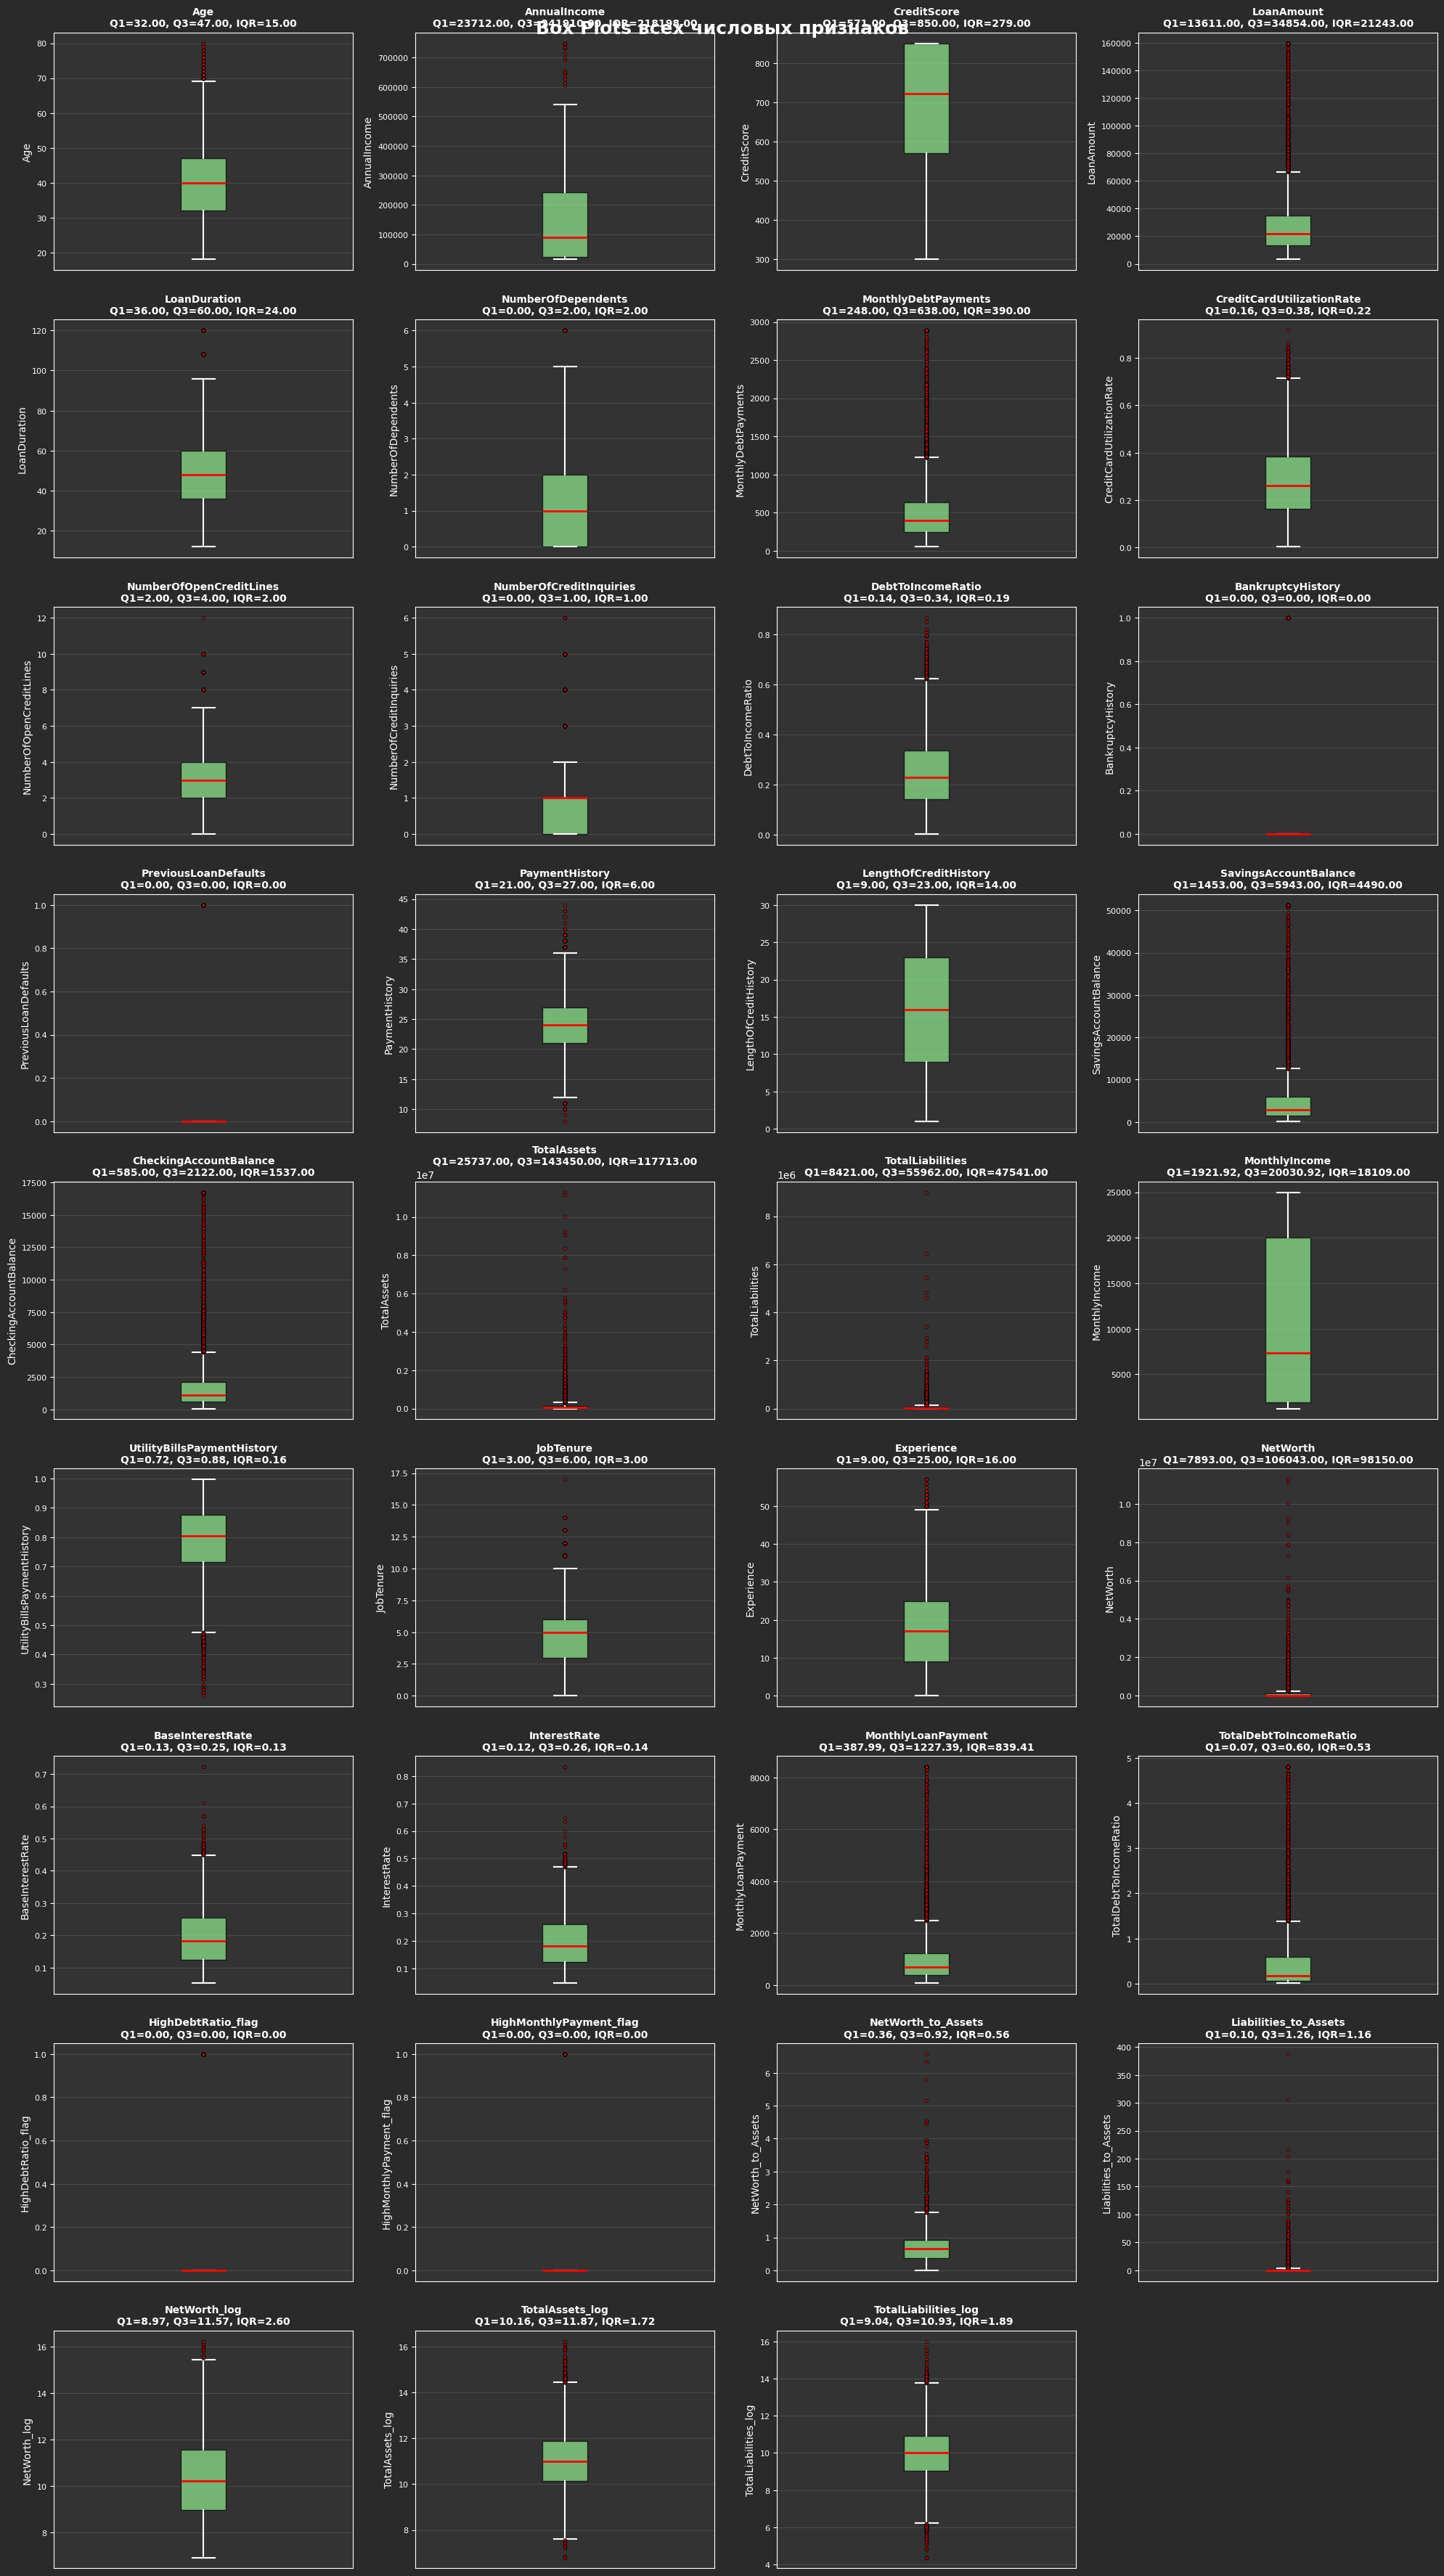


РАСПРЕДЕЛЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ


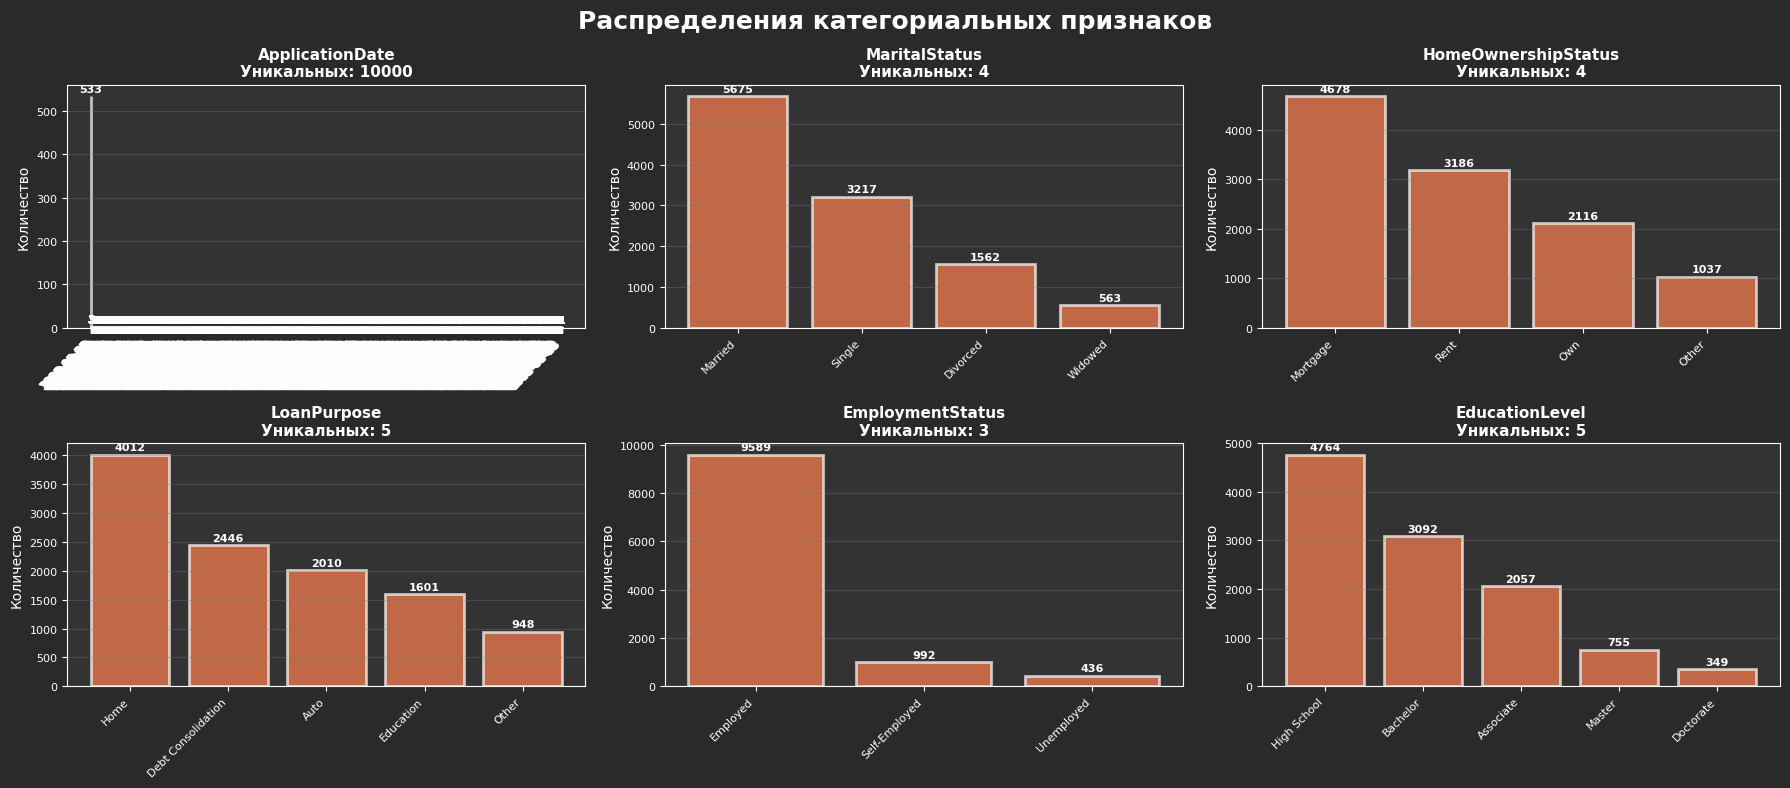


СТАТИСТИКА РАСПРЕДЕЛЕНИЙ


,Feature,Count,Missing,Mean,Median,Std,Min,Max,Skewness,Kurtosis
0,Age,11017,0,39.86,40.00,11.33,18.00,80.00,0.17,-0.22
1,AnnualIncome,11017,0,129539.80,89015.00,113338.90,15000.00,748508.00,0.73,-0.34
2,CreditScore,11017,0,682.24,722.50,167.29,300.00,850.00,-0.81,-0.43
3,LoanAmount,11017,0,28830.14,21828.50,24243.88,3179.56,159547.48,2.37,7.41
4,LoanDuration,11017,0,53.18,48.00,23.93,12.00,120.00,0.74,0.42
5,NumberOfDependents,11017,0,1.54,1.00,1.39,0.00,6.00,0.78,0.07
6,MonthlyDebtPayments,11017,0,528.44,398.00,447.00,52.08,2887.96,2.31,6.87
7,CreditCardUtilizationRate,11017,0,0.28,0.26,0.16,0.00,0.91,0.62,-0.02
8,NumberOfOpenCreditLines,11017,0,3.03,3.00,1.70,0.00,12.00,0.59,0.46
9,NumberOfCreditInquiries,11017,0,0.98,1.00,0.97,0.00,6.00,1.00,0.99



Сохранено: feature_statistics.csv

АНАЛИЗ АСИММЕТРИИ (SKEWNESS)

Сильно скошенные признаки (|skew| > 1):
  TotalLiabilities: 18.58
  Liabilities_to_Assets: 16.87
  NetWorth: 11.14
  TotalAssets: 10.81
  BankruptcyHistory: 4.25
  SavingsAccountBalance: 3.49
  CheckingAccountBalance: 3.37
  MonthlyLoanPayment: 3.23
  HighMonthlyPayment_flag: 3.10
  TotalDebtToIncomeRatio: 2.89
  PreviousLoanDefaults: 2.83
  HighDebtRatio_flag: 2.79
  LoanAmount: 2.37
  MonthlyDebtPayments: 2.31
  NetWorth_to_Assets: 2.19
  NumberOfCreditInquiries: 1.00

Умеренно скошенные признаки (0.5 < |skew| <= 1):
  InterestRate: 0.82
  CreditScore: -0.81
  UtilityBillsPaymentHistory: -0.78
  NumberOfDependents: 0.78
  BaseInterestRate: 0.77
  DebtToIncomeRatio: 0.74
  LoanDuration: 0.74
  AnnualIncome: 0.73
  CreditCardUtilizationRate: 0.62
  NumberOfOpenCreditLines: 0.59
  MonthlyIncome: 0.55

Нормально распределенные признаки (|skew| <= 0.5):
  JobTenure: 0.45
  NetWorth_log: 0.37
  Experience: 0.34
  TotalAssets

In [43]:
train = pd.read_csv('train_for_boosting.csv')

print("АНАЛИЗ РАСПРЕДЕЛЕНИЙ ВСЕХ ПРИЗНАКОВ")
print(f"Датасет: {train.shape}")

# Разделяем признаки по типам
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if 'LoanApproved' in numeric_cols:
    numeric_cols.remove('LoanApproved')

categorical_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nЧисловых признаков: {len(numeric_cols)}")
print(f"Категориальных признаков: {len(categorical_cols)}")

# Гистограммы всех числовых признаков
print("\nГИСТОГРАММЫ ЧИСЛОВЫХ ПРИЗНАКОВ")

n_numeric = len(numeric_cols)
n_cols = 4
n_rows = int(np.ceil(n_numeric / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4), facecolor='#2a2a2a')
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    data = train[col].dropna()
    
    # Гистограмма
    axes[idx].hist(data, bins=50, alpha=0.7, color='skyblue', edgecolor='white')
    
    # Статистика
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()
    skew_val = data.skew()
    
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_val:.2f}')
    axes[idx].axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median={median_val:.2f}')
    
    axes[idx].set_xlabel(col, fontsize=9, color='white')
    axes[idx].set_ylabel('Частота', fontsize=9, color='white')
    axes[idx].set_title(f'{col}\nSkew={skew_val:.2f}, Std={std_val:.2f}',
                        fontweight='bold', fontsize=10, color='white')
    axes[idx].legend(facecolor='#333', edgecolor='white', labelcolor='white', fontsize=7)
    axes[idx].grid(True, alpha=0.3, color='gray')
    axes[idx].set_facecolor('#333')
    axes[idx].tick_params(colors='white', labelsize=8)
    for spine in axes[idx].spines.values():
        spine.set_color('white')

# Скрываем пустые subplot'ы
for idx in range(n_numeric, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Распределения всех числовых признаков', 
             fontsize=18, fontweight='bold', color='white')
plt.tight_layout()
plt.show()


# Box plots всех числовых признаков
print("\nBOX PLOTS ЧИСЛОВЫХ ПРИЗНАКОВ")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4), facecolor='#2a2a2a')
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    data = train[col].dropna()
    
    bp = axes[idx].boxplot(data, vert=True, patch_artist=True,
                           boxprops=dict(facecolor='lightgreen', alpha=0.7),
                           medianprops=dict(color='red', linewidth=2),
                           whiskerprops=dict(linewidth=1.5, color='white'),
                           capprops=dict(linewidth=1.5, color='white'),
                           flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
    
    # Статистика
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    axes[idx].set_ylabel(col, fontsize=10, color='white')
    axes[idx].set_title(f'{col}\nQ1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}',
                        fontweight='bold', fontsize=10, color='white')
    axes[idx].grid(True, alpha=0.3, color='gray', axis='y')
    axes[idx].set_xticks([])
    axes[idx].set_facecolor('#333')
    axes[idx].tick_params(colors='white', labelsize=8)
    for spine in axes[idx].spines.values():
        spine.set_color('white')

# Скрываем пустые subplot'ы
for idx in range(n_numeric, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Box Plots всех числовых признаков', 
             fontsize=18, fontweight='bold', color='white')
plt.tight_layout()
plt.show()



# Категориальные признаки
if len(categorical_cols) > 0:
    print("\nРАСПРЕДЕЛЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
    
    n_cat = len(categorical_cols)
    n_cols_cat = 3
    n_rows_cat = int(np.ceil(n_cat / n_cols_cat))
    
    fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(18, n_rows_cat*4), facecolor='#2a2a2a')
    if n_rows_cat == 1 and n_cols_cat == 1:
        axes = [axes]
    else:
        axes = axes.ravel()
    
    for idx, col in enumerate(categorical_cols):
        value_counts = train[col].value_counts()
        
        axes[idx].bar(range(len(value_counts)), value_counts.values, 
                     color='coral', edgecolor='white', linewidth=2, alpha=0.7)
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=8, color='white')
        axes[idx].set_ylabel('Количество', fontsize=10, color='white')
        axes[idx].set_title(f'{col}\nУникальных: {len(value_counts)}',
                           fontweight='bold', fontsize=11, color='white')
        axes[idx].grid(True, alpha=0.3, color='gray', axis='y')
        axes[idx].set_facecolor('#333')
        axes[idx].tick_params(colors='white', labelsize=8)
        for spine in axes[idx].spines.values():
            spine.set_color('white')
        
        # Добавляем значения на столбцах
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v + max(value_counts.values)*0.01, str(v), 
                          ha='center', va='bottom', fontsize=8, color='white', fontweight='bold')
    
    # Скрываем пустые subplot'ы
    for idx in range(n_cat, len(axes)):
        axes[idx].set_visible(False)
    
    fig.suptitle('Распределения категориальных признаков', 
                 fontsize=18, fontweight='bold', color='white')
    plt.tight_layout()
    plt.show()
    

# Таблица статистики по всем числовым признакам
print("\nСТАТИСТИКА РАСПРЕДЕЛЕНИЙ")

stats_list = []
for col in numeric_cols:
    data = train[col].dropna()
    stats_list.append({
        'Feature': col,
        'Count': len(data),
        'Missing': train[col].isna().sum(),
        'Mean': data.mean(),
        'Median': data.median(),
        'Std': data.std(),
        'Min': data.min(),
        'Max': data.max(),
        'Skewness': data.skew(),
        'Kurtosis': data.kurtosis()
    })

stats_df = pd.DataFrame(stats_list)

styled_stats = stats_df.style.format({
    'Count': '{:.0f}',
    'Missing': '{:.0f}',
    'Mean': '{:.2f}',
    'Median': '{:.2f}',
    'Std': '{:.2f}',
    'Min': '{:.2f}',
    'Max': '{:.2f}',
    'Skewness': '{:.2f}',
    'Kurtosis': '{:.2f}'
}).set_properties(**{
    'text-align': 'center',
    'color': 'white',
    'background-color': '#333'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#444'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#444')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#2a2a2a')]}
])

display(styled_stats)

# Сохраняем статистику
stats_df.to_csv('feature_statistics.csv', index=False)
print("\nСохранено: feature_statistics.csv")

# Анализ асимметрии
print("\nАНАЛИЗ АСИММЕТРИИ (SKEWNESS)")

skew_df = stats_df[['Feature', 'Skewness']].sort_values('Skewness', key=abs, ascending=False)

print("\nСильно скошенные признаки (|skew| > 1):")
high_skew = skew_df[skew_df['Skewness'].abs() > 1]
if len(high_skew) > 0:
    for _, row in high_skew.iterrows():
        print(f"  {row['Feature']}: {row['Skewness']:.2f}")
else:
    print("  Нет сильно скошенных признаков")

print("\nУмеренно скошенные признаки (0.5 < |skew| <= 1):")
mod_skew = skew_df[(skew_df['Skewness'].abs() > 0.5) & (skew_df['Skewness'].abs() <= 1)]
if len(mod_skew) > 0:
    for _, row in mod_skew.iterrows():
        print(f"  {row['Feature']}: {row['Skewness']:.2f}")
else:
    print("  Нет умеренно скошенных признаков")

print("\nНормально распределенные признаки (|skew| <= 0.5):")
norm_skew = skew_df[skew_df['Skewness'].abs() <= 0.5]
if len(norm_skew) > 0:
    for _, row in norm_skew.iterrows():
        print(f"  {row['Feature']}: {row['Skewness']:.2f}")

print("\nАНАЛИЗ ЗАВЕРШЕН")
print("\nСохраненные файлы:")
print("  - distributions_numeric.png")
print("  - boxplots_numeric.png")
if len(categorical_cols) > 0:
    print("  - distributions_categorical.png")
print("  - feature_statistics.csv")


# Реализовать класс бэггинга, который для обучения методом fit обучает n базовых моделей b. Сравнить полученные после обучения результаты с реализацией из sklearn.

In [44]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

class CustomBaggingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=None, n_estimators=10, max_samples=1.0, 
                 max_features=1.0, bootstrap=True, random_state=None):
        '''
        Кастомная реализация бэггинга
        
        base_estimator: базовая модель (по умолчанию DecisionTree)
        n_estimators: количество базовых моделей
        max_samples: доля/количество сэмплов для каждой модели
        max_features: доля/количество признаков для каждой модели
        bootstrap: использовать ли бутстрэп (с возвратом)
        random_state: seed для воспроизводимости
        '''
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.estimators_ = []
        self.feature_indices_ = []
        
    def _get_bootstrap_sample(self, X, y, rng):
        '''Создает bootstrap-выборку'''
        n_samples = X.shape[0]
        
        # Определяем размер выборки
        if isinstance(self.max_samples, float):
            sample_size = int(n_samples * self.max_samples)
        else:
            sample_size = min(self.max_samples, n_samples)
        
        # Сэмплируем индексы
        if self.bootstrap:
            indices = rng.choice(n_samples, size=sample_size, replace=True)
        else:
            indices = rng.choice(n_samples, size=sample_size, replace=False)
        
        return X[indices], y[indices], indices
    
    def _get_feature_indices(self, n_features, rng):
        '''Выбирает случайный набор признаков'''
        if isinstance(self.max_features, float):
            n_features_subset = max(1, int(n_features * self.max_features))
        else:
            n_features_subset = min(self.max_features, n_features)
        
        return rng.choice(n_features, size=n_features_subset, replace=False)
    
    def fit(self, X, y):
        '''Обучение ансамбля моделей'''
        # Конвертируем в numpy если нужно
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values
        
        # Инициализируем random state
        rng = np.random.RandomState(self.random_state)
        
        # Базовая модель по умолчанию
        if self.base_estimator is None:
            self.base_estimator = DecisionTreeClassifier(max_depth=10, random_state=self.random_state)
        
        n_samples, n_features = X.shape
        self.estimators_ = []
        self.feature_indices_ = []
        
        print(f"Обучаем {self.n_estimators} базовых моделей...")
        
        for i in range(self.n_estimators):
            # Клонируем базовую модель
            estimator = clone(self.base_estimator)
            
            # Получаем bootstrap-выборку
            X_sample, y_sample, _ = self._get_bootstrap_sample(X, y, rng)
            
            # Выбираем подмножество признаков
            feature_indices = self._get_feature_indices(n_features, rng)
            X_sample_subset = X_sample[:, feature_indices]
            
            # Обучаем модель
            estimator.fit(X_sample_subset, y_sample)
            
            # Сохраняем
            self.estimators_.append(estimator)
            self.feature_indices_.append(feature_indices)
            
            if (i + 1) % 10 == 0 or (i + 1) == self.n_estimators:
                print(f"  Обучено {i + 1}/{self.n_estimators} моделей")
        
        return self
    
    def predict_proba(self, X):
        '''Предсказание вероятностей'''
        if isinstance(X, pd.DataFrame):
            X = X.values
        
        # Собираем предсказания от всех моделей
        predictions = np.zeros((X.shape[0], 2))  # для бинарной классификации
        
        for estimator, feature_indices in zip(self.estimators_, self.feature_indices_):
            X_subset = X[:, feature_indices]
            predictions += estimator.predict_proba(X_subset)
        
        # Усредняем
        predictions /= self.n_estimators
        
        return predictions
    
    def predict(self, X):
        '''Предсказание классов'''
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)

# Загрузка данных
print("СРАВНЕНИЕ КАСТОМНОГО БЭГГИНГА С SKLEARN")

train = pd.read_csv('train_for_boosting.csv')

# Подготовка данных
X = train.drop('LoanApproved', axis=1)
y = train['LoanApproved']

# Убираем категориальные признаки для простоты
X = X.select_dtypes(include=[np.number])

print(f"\nДанные: {X.shape[0]} строк, {X.shape[1]} признаков")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Test: {X_test.shape[0]} строк")

# Базовая модель
base_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Кастомный бэггинг
print("\nКАСТОМНЫЙ БЭГГИНГ")

custom_bagging = CustomBaggingClassifier(
    base_estimator=base_model,
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42
)

custom_bagging.fit(X_train, y_train)

y_pred_custom = custom_bagging.predict(X_test)
y_proba_custom = custom_bagging.predict_proba(X_test)[:, 1]

acc_custom = accuracy_score(y_test, y_pred_custom)
roc_custom = roc_auc_score(y_test, y_proba_custom)

print(f"\nРезультаты кастомного бэггинга:")
print(f"  Accuracy: {acc_custom:.4f}")
print(f"  ROC-AUC:  {roc_custom:.4f}")

# Sklearn бэггинг
print("\nSKLEARN BAGGING")

sklearn_bagging = BaggingClassifier(
    estimator=base_model,
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

print(f"Обучаем sklearn BaggingClassifier...")
sklearn_bagging.fit(X_train, y_train)

y_pred_sklearn = sklearn_bagging.predict(X_test)
y_proba_sklearn = sklearn_bagging.predict_proba(X_test)[:, 1]

acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
roc_sklearn = roc_auc_score(y_test, y_proba_sklearn)

print(f"\nРезультаты sklearn бэггинга:")
print(f"  Accuracy: {acc_sklearn:.4f}")
print(f"  ROC-AUC:  {roc_sklearn:.4f}")

# Сравнение
print("\nСРАВНЕНИЕ РЕЗУЛЬТАТОВ")

comparison_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'ROC-AUC'],
    'Кастомный': [acc_custom, roc_custom],
    'Sklearn': [acc_sklearn, roc_sklearn],
    'Разница': [abs(acc_custom - acc_sklearn), abs(roc_custom - roc_sklearn)]
})

display(comparison_df)

print(f"\nМаксимальная разница: {comparison_df['Разница'].max():.6f}")

if comparison_df['Разница'].max() < 0.01:
    print("Результаты практически идентичны! Реализация корректна.")
else:
    print("Небольшие различия - возможно из-за разного порядка сэмплирования")

# Детальный отчет
print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ (Кастомный)")
print(classification_report(y_test, y_pred_custom, target_names=['Rejected', 'Approved']))

print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ (Sklearn)")
print(classification_report(y_test, y_pred_sklearn, target_names=['Rejected', 'Approved']))


СРАВНЕНИЕ КАСТОМНОГО БЭГГИНГА С SKLEARN

Данные: 11017 строк, 35 признаков
Train: 8813 строк
Test: 2204 строк

КАСТОМНЫЙ БЭГГИНГ
Обучаем 50 базовых моделей...
  Обучено 10/50 моделей
  Обучено 20/50 моделей
  Обучено 30/50 моделей
  Обучено 40/50 моделей
  Обучено 50/50 моделей

Результаты кастомного бэггинга:
  Accuracy: 0.9256
  ROC-AUC:  0.9795

SKLEARN BAGGING
Обучаем sklearn BaggingClassifier...

Результаты sklearn бэггинга:
  Accuracy: 0.9260
  ROC-AUC:  0.9801

СРАВНЕНИЕ РЕЗУЛЬТАТОВ


,Метрика,Кастомный,Sklearn,Разница
0,Accuracy,0.925590,0.926044,0.000454
1,ROC-AUC,0.979523,0.980098,0.000575



Максимальная разница: 0.000575
Результаты практически идентичны! Реализация корректна.

ДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ (Кастомный)
              precision    recall  f1-score   support

    Rejected       0.93      0.91      0.92      1024
    Approved       0.92      0.94      0.93      1180

    accuracy                           0.93      2204
   macro avg       0.93      0.92      0.93      2204
weighted avg       0.93      0.93      0.93      2204


ДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ (Sklearn)
              precision    recall  f1-score   support

    Rejected       0.93      0.91      0.92      1024
    Approved       0.92      0.94      0.93      1180

    accuracy                           0.93      2204
   macro avg       0.93      0.93      0.93      2204
weighted avg       0.93      0.93      0.93      2204



# Реализовать класс градиентного бустинга, который для обучения методом fit обучает n базовых моделей b. Сравнить полученные после обучения результаты с реализацией из sklearn и других библиотек.

In [45]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

class CustomGradientBoostingClassifier:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, 
                 min_samples_split=2, random_state=None):
        '''
        Кастомная реализация градиентного бустинга для бинарной классификации
        
        Параметры:
        n_estimators: количество деревьев (итераций бустинга)
        learning_rate: шаг обучения (shrinkage)
        max_depth: максимальная глубина деревьев
        min_samples_split: минимальное количество сэмплов для split'а
        random_state: seed для воспроизводимости
        '''
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.trees = []
        self.initial_prediction = None
        
    def _sigmoid(self, x):
        '''Сигмоида для перевода в вероятности'''
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def _compute_gradients(self, y_true, y_pred_proba):
        '''Вычисляем градиенты для log-loss (бинарная кросс-энтропия)'''
        return y_true - y_pred_proba
    
    def fit(self, X, y):
        '''Обучение градиентного бустинга'''
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values
        
        # Инициализация: начальное предсказание = log(p/(1-p))
        mean_y = np.mean(y)
        self.initial_prediction = np.log(mean_y / (1 - mean_y + 1e-10))
        
        # Текущие предсказания (в логитах)
        F = np.full(len(y), self.initial_prediction)
        
        print(f"Обучаем градиентный бустинг ({self.n_estimators} деревьев)...")
        print(f"Начальное предсказание (logit): {self.initial_prediction:.4f}")
        
        for i in range(self.n_estimators):
            # Переводим в вероятности
            probabilities = self._sigmoid(F)
            
            # Вычисляем градиенты (остатки)
            gradients = self._compute_gradients(y, probabilities)
            
            # Обучаем дерево на градиентах
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                random_state=self.random_state + i if self.random_state else None
            )
            tree.fit(X, gradients)
            
            # Предсказания дерева
            tree_predictions = tree.predict(X)
            
            # Обновляем F с learning rate
            F += self.learning_rate * tree_predictions
            
            # Сохраняем дерево
            self.trees.append(tree)
            
            # Логируем прогресс
            if (i + 1) % 20 == 0 or (i + 1) == self.n_estimators:
                current_acc = accuracy_score(y, (probabilities >= 0.5).astype(int))
                print(f"  Итерация {i+1}/{self.n_estimators}: Train Accuracy = {current_acc:.4f}")
        
        return self
    
    def predict_proba(self, X):
        '''Предсказание вероятностей'''
        if isinstance(X, pd.DataFrame):
            X = X.values
        
        # Начинаем с базового предсказания
        F = np.full(X.shape[0], self.initial_prediction)
        
        # Суммируем предсказания всех деревьев
        for tree in self.trees:
            F += self.learning_rate * tree.predict(X)
        
        # Переводим в вероятности через сигмоиду
        probabilities = self._sigmoid(F)
        
        # Возвращаем в формате sklearn: [prob_class_0, prob_class_1]
        return np.vstack([1 - probabilities, probabilities]).T
    
    def predict(self, X):
        '''Предсказание классов'''
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)

# Загрузка и подготовка данных
print("СРАВНЕНИЕ КАСТОМНОГО ГРАДИЕНТНОГО БУСТИНГА С SKLEARN")

# Загружаем данные
train = pd.read_csv('train_for_boosting.csv')

# Подготовка данных
X = train.drop('LoanApproved', axis=1)
y = train['LoanApproved']

# Убираем категориальные признаки
X = X.select_dtypes(include=[np.number])

print(f"\nДанные: {X.shape[0]} строк, {X.shape[1]} признаков")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Test: {X_test.shape[0]} строк")
print(f"Баланс классов: {y_train.value_counts().to_dict()}")

# Кастомный градиентный бустинг
print("\nКАСТОМНЫЙ ГРАДИЕНТНЫЙ БУСТИНГ")

custom_gb = CustomGradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    random_state=42
)

custom_gb.fit(X_train, y_train)

# Предсказания
y_pred_custom = custom_gb.predict(X_test)
y_proba_custom = custom_gb.predict_proba(X_test)[:, 1]

# Метрики
acc_custom = accuracy_score(y_test, y_pred_custom)
roc_custom = roc_auc_score(y_test, y_proba_custom)

print(f"\nРезультаты кастомного градиентного бустинга:")
print(f"  Accuracy: {acc_custom:.4f}")
print(f"  ROC-AUC:  {roc_custom:.4f}")

# Sklearn градиентный бустинг
print("\nSKLEARN GRADIENT BOOSTING")

sklearn_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    random_state=42,
    verbose=0
)

print("Обучаем sklearn GradientBoostingClassifier...")
sklearn_gb.fit(X_train, y_train)

# Предсказания
y_pred_sklearn = sklearn_gb.predict(X_test)
y_proba_sklearn = sklearn_gb.predict_proba(X_test)[:, 1]

# Метрики
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
roc_sklearn = roc_auc_score(y_test, y_proba_sklearn)

print(f"\nРезультаты sklearn градиентного бустинга:")
print(f"  Accuracy: {acc_sklearn:.4f}")
print(f"  ROC-AUC:  {roc_sklearn:.4f}")

# Сравнение результатов
print("\nСРАВНЕНИЕ РЕЗУЛЬТАТОВ")

comparison_df = pd.DataFrame({
    'Модель': ['Кастомный GB', 'Sklearn GB'],
    'Accuracy': [acc_custom, acc_sklearn],
    'ROC-AUC': [roc_custom, roc_sklearn]
})

print("\n", comparison_df.to_string(index=False))

print(f"\nРазница в Accuracy: {abs(acc_custom - acc_sklearn):.4f}")
print(f"Разница в ROC-AUC:  {abs(roc_custom - roc_sklearn):.4f}")

if abs(acc_custom - acc_sklearn) < 0.02:
    print("\nРезультаты очень близки! Реализация корректна.")
else:
    print("\nЕсть некоторые различия (могут быть из-за деталей имплементации)")

# Детальный отчет
print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ")

print("\nКастомный Градиентный Бустинг:")
print(classification_report(y_test, y_pred_custom, target_names=['Rejected', 'Approved']))

print("\nSklearn Градиентный Бустинг:")
print(classification_report(y_test, y_pred_sklearn, target_names=['Rejected', 'Approved']))



СРАВНЕНИЕ КАСТОМНОГО ГРАДИЕНТНОГО БУСТИНГА С SKLEARN

Данные: 11017 строк, 35 признаков
Train: 8813 строк
Test: 2204 строк
Баланс классов: {1.0: 4717, 0.0: 4096}

КАСТОМНЫЙ ГРАДИЕНТНЫЙ БУСТИНГ
Обучаем градиентный бустинг (100 деревьев)...
Начальное предсказание (logit): 0.1412
  Итерация 20/100: Train Accuracy = 0.9139
  Итерация 40/100: Train Accuracy = 0.9189
  Итерация 60/100: Train Accuracy = 0.9228
  Итерация 80/100: Train Accuracy = 0.9258
  Итерация 100/100: Train Accuracy = 0.9265

Результаты кастомного градиентного бустинга:
  Accuracy: 0.9201
  ROC-AUC:  0.9766

SKLEARN GRADIENT BOOSTING
Обучаем sklearn GradientBoostingClassifier...

Результаты sklearn градиентного бустинга:
  Accuracy: 0.9274
  ROC-AUC:  0.9823

СРАВНЕНИЕ РЕЗУЛЬТАТОВ

       Модель  Accuracy  ROC-AUC
Кастомный GB  0.920145 0.976625
  Sklearn GB  0.927405 0.982284

Разница в Accuracy: 0.0073
Разница в ROC-AUC:  0.0057

Результаты очень близки! Реализация корректна.

ДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ

Кастомный Гр

# Сравнить результаты работы алгоритмов градиентного бустинга: реализация из sklearn, LightGBM, XGBoost, CatBoost. Выбрать алгоритм с лучшей метрикой на данных.

- 0.5p. Реализовать метрику Accuracy, протестировать и сравнить полученный результат с Accuracy из sklearn.
- 0.5p. Реализовать Precision, протестировать и сравнить с метрикой из sklearn.
- 0.5p. Реализовать Recall, протестировать и сравнить с метрикой из sklearn.
- 0.5p. Реализовать F1-score, протестировать и сравнить с метрикой из sklearn.
- Дополнительные 2 балла можно получить за реализацию метрик AUC-ROC и AUC-
PR и последующее сравнение с готовыми реализациями.

In [46]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, average_precision_score)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Самописные метрики
def custom_accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def custom_precision(y_true, y_pred, pos_label=1):
    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    fp = np.sum((y_true != pos_label) & (y_pred == pos_label))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def custom_recall(y_true, y_pred, pos_label=1):
    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    fn = np.sum((y_true == pos_label) & (y_pred != pos_label))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def custom_f1_score(y_true, y_pred, pos_label=1):
    prec = custom_precision(y_true, y_pred, pos_label)
    rec = custom_recall(y_true, y_pred, pos_label)
    return 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

def custom_auc_roc(y_true, y_proba):
    order = np.argsort(y_proba)[::-1]
    y_true_sorted = y_true[order]
    
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)
    
    if n_pos == 0 or n_neg == 0:
        return 0.5
    
    tpr_values = [0]
    fpr_values = [0]
    tp = 0
    fp = 0
    
    for i in range(len(y_true_sorted)):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1
        tpr_values.append(tp / n_pos)
        fpr_values.append(fp / n_neg)
    
    auc = 0
    for i in range(1, len(fpr_values)):
        auc += (fpr_values[i] - fpr_values[i-1]) * (tpr_values[i] + tpr_values[i-1]) / 2
    
    return auc

def custom_auc_pr(y_true, y_proba):
    order = np.argsort(y_proba)[::-1]
    y_true_sorted = y_true[order]
    
    n_pos = np.sum(y_true == 1)
    if n_pos == 0:
        return 0.0
    
    precision_values = [1.0]
    recall_values = [0.0]
    tp = 0
    fp = 0
    
    for i in range(len(y_true_sorted)):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1
        precision_values.append(tp / (tp + fp))
        recall_values.append(tp / n_pos)
    
    auc = 0
    for i in range(1, len(recall_values)):
        auc += (recall_values[i] - recall_values[i-1]) * (precision_values[i] + precision_values[i-1]) / 2
    
    return auc

# Загрузка и подготовка данных
print("СРАВНЕНИЕ АЛГОРИТМОВ ГРАДИЕНТНОГО БУСТИНГА")

train = pd.read_csv('train_for_boosting.csv')
print(f"\nИсходные данные: {train.shape}")

# Удаляем строки с NaN в целевой переменной
train = train.dropna(subset=['LoanApproved'])

X = train.drop(['LoanApproved'], axis=1)
y = train['LoanApproved'].astype(int)

print(f"\nПропуски до обработки: {X.isnull().sum().sum()}")

# Обработка признаков
print("\nОБРАБОТКА ПРИЗНАКОВ")

# Находим категориальные признаки
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nКатегориальные признаки: {categorical_cols}")

# Обрабатываем категориальные признаки
for col in categorical_cols:
    print(f"\nОбработка {col}...")
    # Пробуем преобразовать в дату
    try:
        X[col] = pd.to_datetime(X[col], errors='coerce')
        # Извлекаем компоненты даты
        X[f'{col}_year'] = X[col].dt.year
        X[f'{col}_month'] = X[col].dt.month
        X[f'{col}_day'] = X[col].dt.day
        X[f'{col}_dayofweek'] = X[col].dt.dayofweek
        print(f"  Дата: извлечены компоненты")
        # Удаляем исходную колонку
        X = X.drop(col, axis=1)
    except:
        # Label encoding для категориальных
        X[col] = pd.Categorical(X[col]).codes
        print(f"  Label encoding")

print(f"\nПосле обработки категориальных: {X.shape[1]} признаков")

# Заполняем все NaN
print(f"\nПропусков перед заполнением: {X.isnull().sum().sum()}")

# Заполняем NaN медианой для каждой колонки
for col in X.columns:
    if X[col].isnull().sum() > 0:
        median_value = X[col].median()
        # Если медиана тоже NaN (вся колонка пустая), используем 0
        if pd.isna(median_value):
            X[col] = X[col].fillna(0)
            print(f"  {col}: заполнено нулями (вся колонка пустая)")
        else:
            X[col] = X[col].fillna(median_value)
            print(f"  {col}: заполнено медианой ({median_value:.2f})")

# Проверяем на inf и -inf
print(f"\nПроверка на inf...")
for col in X.columns:
    if np.isinf(X[col]).any():
        print(f"  {col}: найдены inf, заменяем на медиану")
        X[col] = X[col].replace([np.inf, -np.inf], np.nan)
        X[col] = X[col].fillna(X[col].median())

# Финальная проверка
print(f"\nПропусков после обработки: {X.isnull().sum().sum()}")
print(f"Inf значений: {np.isinf(X.values).sum()}")
print(f"Итого признаков: {X.shape[1]}")
print(f"Все признаки числовые: {X.select_dtypes(include=['number']).shape[1] == X.shape[1]}")

print(f"\nРаспределение классов: {dict(y.value_counts())}")

# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Обучение моделей
print("\nОБУЧЕНИЕ МОДЕЛЕЙ")

models = {}
results = []

# 1. Sklearn GB
print("\n[1/4] Sklearn GradientBoosting...")
sklearn_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=0
)
sklearn_gb.fit(X_train, y_train)
models['Sklearn GB'] = sklearn_gb

# 2. LightGBM
print("[2/4] LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
models['LightGBM'] = lgb_model

# 3. XGBoost
print("[3/4] XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model

# 4. CatBoost
print("[4/4] CatBoost...")
catboost_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=5,
    random_state=42,
    verbose=0
)
catboost_model.fit(X_train, y_train)
models['CatBoost'] = catboost_model

# Оценка моделей
print("\nРЕЗУЛЬТАТЫ МОДЕЛЕЙ")

for model_name, model in models.items():
    print(f"\nМОДЕЛЬ: {model_name}")
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    custom_metrics = {
        'Accuracy': custom_accuracy(y_test.values, y_pred),
        'Precision': custom_precision(y_test.values, y_pred),
        'Recall': custom_recall(y_test.values, y_pred),
        'F1-Score': custom_f1_score(y_test.values, y_pred),
        'AUC-ROC': custom_auc_roc(y_test.values, y_proba),
        'AUC-PR': custom_auc_pr(y_test.values, y_proba)
    }
    
    sklearn_metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'AUC-PR': average_precision_score(y_test, y_proba)
    }
    
    model_comparison = pd.DataFrame({
        'Custom': custom_metrics,
        'Sklearn': sklearn_metrics
    })
    model_comparison['Diff'] = np.abs(model_comparison['Custom'] - model_comparison['Sklearn'])
    
    print("\n" + model_comparison.to_string())
    
    for metric_name in custom_metrics.keys():
        results.append({
            'Model': model_name,
            'Metric': metric_name,
            'Custom': custom_metrics[metric_name],
            'Sklearn': sklearn_metrics[metric_name],
            'Diff': np.abs(custom_metrics[metric_name] - sklearn_metrics[metric_name])
        })

# Итоговое сравнение
print("\nИТОГОВОЕ СРАВНЕНИЕ")

results_df = pd.DataFrame(results)
pivot_custom = results_df.pivot(index='Model', columns='Metric', values='Custom')
pivot_custom = pivot_custom[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']]

print("\nСамописные метрики:")
print(pivot_custom.to_string())

print("\nЛУЧШИЕ МОДЕЛИ ПО МЕТРИКАМ:")
for metric in pivot_custom.columns:
    best_model = pivot_custom[metric].idxmax()
    best_score = pivot_custom[metric].max()
    print(f"{metric:12s}: {best_model:15s} = {best_score:.4f}")

print("\nСРЕДНИЙ РАНГ:")
ranks = pivot_custom.rank(ascending=False)
mean_rank = ranks.mean(axis=1).sort_values()
for model, rank in mean_rank.items():
    print(f"{model:15s}: {rank:.2f}")

print(f"\nПОБЕДИТЕЛЬ: {mean_rank.idxmin()}")

print("\nПРОВЕРКА КОРРЕКТНОСТИ МЕТРИК")
max_diff = results_df.groupby('Metric')['Diff'].max()
print("\nМаксимальная разница Custom vs Sklearn:")
print(max_diff.to_string())

if max_diff.max() < 1e-10:
    print("\nМЕТРИКИ ИДЕНТИЧНЫ!")
elif max_diff.max() < 1e-6:
    print("\nМетрики практически идентичны (diff < 1e-6)")
else:
    print(f"\nНебольшие расхождения: {max_diff.max():.2e}")

results_df.to_csv('boosting_comparison_results.csv', index=False)
pivot_custom.to_csv('boosting_models_summary.csv')




СРАВНЕНИЕ АЛГОРИТМОВ ГРАДИЕНТНОГО БУСТИНГА

Исходные данные: (11017, 42)

Пропуски до обработки: 0

ОБРАБОТКА ПРИЗНАКОВ

Категориальные признаки: ['ApplicationDate', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']

Обработка ApplicationDate...
  Дата: извлечены компоненты

Обработка MaritalStatus...
  Дата: извлечены компоненты

Обработка HomeOwnershipStatus...
  Дата: извлечены компоненты

Обработка LoanPurpose...
  Дата: извлечены компоненты

Обработка EmploymentStatus...
  Дата: извлечены компоненты

Обработка EducationLevel...
  Дата: извлечены компоненты

После обработки категориальных: 59 признаков

Пропусков перед заполнением: 220340
  MaritalStatus_year: заполнено нулями (вся колонка пустая)
  MaritalStatus_month: заполнено нулями (вся колонка пустая)
  MaritalStatus_day: заполнено нулями (вся колонка пустая)
  MaritalStatus_dayofweek: заполнено нулями (вся колонка пустая)
  HomeOwnershipStatus_year: заполнено нулями (вся колонка пус

submisson

In [47]:
# Функция обработки данных
def preprocess_data(df, is_train=True):
    """Обработка данных (одинаково для train и test)"""
    
    if is_train:
        df = df.dropna(subset=['LoanApproved'])
        X = df.drop(['LoanApproved'], axis=1)
        y = df['LoanApproved'].astype(int)
    else:
        # Сохраняем ID для submission
        ids = df['ID'].copy()
        X = df.drop(['ID'], axis=1) if 'ID' in df.columns else df.copy()
        y = None
    
    # Обрабатываем категориальные признаки
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    
    for col in categorical_cols:
        try:
            X[col] = pd.to_datetime(X[col], errors='coerce')
            X[f'{col}_year'] = X[col].dt.year
            X[f'{col}_month'] = X[col].dt.month
            X[f'{col}_day'] = X[col].dt.day
            X[f'{col}_dayofweek'] = X[col].dt.dayofweek
            X = X.drop(col, axis=1)
        except:
            X[col] = pd.Categorical(X[col]).codes
    
    # Заполняем пропуски
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            median_val = X[col].median()
            X[col] = X[col].fillna(0 if pd.isna(median_val) else median_val)
    
    # Обработка inf
    for col in X.columns:
        if np.isinf(X[col]).any():
            X[col] = X[col].replace([np.inf, -np.inf], np.nan)
            X[col] = X[col].fillna(X[col].median())
    
    if is_train:
        return X, y
    else:
        return X, ids

# Загрузка данных
print("\n[1/4] Загрузка данных...")
train = pd.read_csv('train_for_boosting.csv')
test = pd.read_csv('test_c.csv')

print(f"Train: {train.shape}, Test: {test.shape}")

# Обработка данных
print("\n[2/4] Обработка данных...")
X_train_full, y_train_full = preprocess_data(train, is_train=True)
X_test, test_ids = preprocess_data(test, is_train=False)

print(f"Train обработан: {X_train_full.shape}")
print(f"Test обработан: {X_test.shape}")

# Выравниваем колонки (на случай если в test есть новые категории)
missing_cols = set(X_train_full.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

extra_cols = set(X_test.columns) - set(X_train_full.columns)
for col in extra_cols:
    X_test = X_test.drop(col, axis=1)

X_test = X_test[X_train_full.columns]

print(f"После выравнивания: Train {X_train_full.shape}, Test {X_test.shape}")

# Обучение модели
print("\n[3/4] Обучение CatBoost...")

# Используем больше итераций для лучшего результата
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=100
)

model.fit(X_train_full, y_train_full)

# Предсказание и создание submission
print("\n[4/4] Создание submission...")

# Предсказываем вероятности
predictions = model.predict(X_test)

# Создаем submission файл
submission = pd.DataFrame({
    'ID': test_ids,
    'LoanApproved': predictions
})

# Сохраняем
submission.to_csv('submission.csv', index=False)

print(f"\nФайл: submission.csv")
print(f"Строк: {len(submission)}")




[1/4] Загрузка данных...
Train: (11017, 42), Test: (5000, 35)

[2/4] Обработка данных...
Train обработан: (11017, 59)
Test обработан: (5000, 52)
После выравнивания: Train (11017, 59), Test (5000, 59)

[3/4] Обучение CatBoost...
0:	learn: 0.6386449	total: 6.36ms	remaining: 3.17s
100:	learn: 0.1484348	total: 267ms	remaining: 1.05s
200:	learn: 0.1221018	total: 536ms	remaining: 797ms
300:	learn: 0.1019219	total: 798ms	remaining: 527ms
400:	learn: 0.0866125	total: 1.06s	remaining: 261ms
499:	learn: 0.0741021	total: 1.33s	remaining: 0us

[4/4] Создание submission...

Файл: submission.csv
Строк: 5000


# Подобрать оптимальные гиперпараметры для лучшей модели с помощью Optuna.

In [48]:
import optuna
from optuna.samplers import TPESampler


# Функция обработки данных
def preprocess_data(df, is_train=True):
    if is_train:
        df = df.dropna(subset=['LoanApproved'])
        X = df.drop(['LoanApproved'], axis=1)
        y = df['LoanApproved'].astype(int)
    else:
        ids = df['ID'].copy()
        X = df.drop(['ID'], axis=1) if 'ID' in df.columns else df.copy()
        y = None
    
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    
    for col in categorical_cols:
        try:
            X[col] = pd.to_datetime(X[col], errors='coerce')
            X[f'{col}_year'] = X[col].dt.year
            X[f'{col}_month'] = X[col].dt.month
            X[f'{col}_day'] = X[col].dt.day
            X[f'{col}_dayofweek'] = X[col].dt.dayofweek
            X = X.drop(col, axis=1)
        except:
            X[col] = pd.Categorical(X[col]).codes
    
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            median_val = X[col].median()
            X[col] = X[col].fillna(0 if pd.isna(median_val) else median_val)
    
    for col in X.columns:
        if np.isinf(X[col]).any():
            X[col] = X[col].replace([np.inf, -np.inf], np.nan)
            X[col] = X[col].fillna(X[col].median())
    
    if is_train:
        return X, y
    else:
        return X, ids

print("\n[1/3] Загрузка данных")
train = pd.read_csv('train_for_boosting.csv')
test = pd.read_csv('test_c.csv')

X_train, y_train = preprocess_data(train, is_train=True)
X_test, test_ids = preprocess_data(test, is_train=False)

# Выравнивание колонок
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
extra_cols = set(X_test.columns) - set(X_train.columns)
X_test = X_test.drop(columns=list(extra_cols), errors='ignore')
X_test = X_test[X_train.columns]

print(f"Данные готовы: Train {X_train.shape}, Test {X_test.shape}")

# Optuna: objective функция с ручной CV
def objective(trial):
    """Функция для оптимизации"""
    
    # Гиперпараметры для подбора
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'random_state': 42,
        'verbose': 0
    }
    
    # Ручная кросс-валидация
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Обучаем модель
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=0)
        
        # Предсказываем вероятности
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # Считаем AUC-ROC
        auc = roc_auc_score(y_val, y_pred_proba)
        scores.append(auc)
    
    return np.mean(scores)

# Запуск оптимизации
print("\n[2/3] Запуск Optuna...")

# Создаем study
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='catboost_optimization'
)

# Запускаем оптимизацию
study.optimize(
    objective, 
    n_trials=30,
    show_progress_bar=True
)

print("\nРЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ")

print(f"\nЛучший CV AUC-ROC: {study.best_value:.6f}")
print(f"Количество trials: {len(study.trials)}")

print("\nОптимальные гиперпараметры:")
for param, value in study.best_params.items():
    print(f"{param:25s}: {value}")

# Обучение финальной модели
print("\n[3/3] Обучение финальной модели...")

best_model = CatBoostClassifier(**study.best_params, random_state=42, verbose=100)
best_model.fit(X_train, y_train)

# Предсказание
predictions = best_model.predict(X_test)

# Submission
submission = pd.DataFrame({
    'ID': test_ids,
    'LoanApproved': predictions
})

submission.to_csv('submission_optuna.csv', index=False)

print("\nОПТИМИЗАЦИЯ ЗАВЕРШЕНА")
print(f"\nФайл: submission_optuna.csv")
print(f"Строк: {len(submission)}")
print(f"\nПредсказания:")
print(submission['LoanApproved'].value_counts())

# Сохраняем историю
optuna_results = pd.DataFrame({
    'trial': range(len(study.trials)),
    'auc_roc': [t.value for t in study.trials],
    'params': [str(t.params) for t in study.trials]
})
optuna_results = optuna_results.sort_values('auc_roc', ascending=False)
optuna_results.to_csv('optuna_history.csv', index=False)

# Топ-5 результатов
print("\nТОП-5 ЛУЧШИХ КОНФИГУРАЦИЙ:")
for idx, row in optuna_results.head(5).iterrows():
    print(f"\n#{row['trial']+1}: AUC-ROC = {row['auc_roc']:.6f}")

print("\nСРАВНЕНИЕ:")
print(f"Базовая модель (тест):  0.9826")
print(f"После Optuna (CV):      {study.best_value:.6f}")
improvement = (study.best_value - 0.9826) * 100
print(f"Изменение:              {improvement:+.3f}%")


[I 2025-12-14 16:15:24,126] A new study created in memory with name: catboost_optimization



[1/3] Загрузка данных
Данные готовы: Train (11017, 59), Test (5000, 59)

[2/3] Запуск Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-14 16:15:25,840] Trial 0 finished with value: 0.9839117118484584 and parameters: {'iterations': 749, 'learning_rate': 0.2536999076681771, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'bagging_temperature': 0.15599452033620265, 'random_strength': 0.5808361216819946}. Best is trial 0 with value: 0.9839117118484584.
[I 2025-12-14 16:15:31,401] Trial 1 finished with value: 0.985031399626991 and parameters: {'iterations': 1340, 'learning_rate': 0.07725378389307355, 'depth': 8, 'l2_leaf_reg': 1.185260448662222, 'border_count': 249, 'bagging_temperature': 0.8324426408004217, 'random_strength': 2.1233911067827616}. Best is trial 1 with value: 0.985031399626991.
[I 2025-12-14 16:15:36,427] Trial 2 finished with value: 0.9833780184276211 and parameters: {'iterations': 518, 'learning_rate': 0.018659959624904923, 'depth': 6, 'l2_leaf_reg': 5.72280788469014, 'border_count': 128, 'bagging_temperature': 0.2912291401980419, 'random_strength': 6.118528947223795}. Best is